# Tokenization Homework: Llama 2 vs Llama 3

In this assignment, we will investigate the differences in how English and Persian texts are tokenized by two popular language models: Llama 2 and Llama 3. 

**Important Notes for this Assignment:**
1. **No GPU Required:** We are ONLY loading the tokenizers, not the massive model weights. Tokenizers are very small files (just a few megabytes) and run perfectly fast on any standard laptop CPU.
2. **Small Download Size:** By using `AutoTokenizer.from_pretrained()`, the code will *only* download the tokenizer configuration files (`tokenizer.json`, `tokenizer.model`, etc.). It will **NOT** download the gigabytes of `.safetensors` or `.bin` model weights. The total download will be less than 5 MB.
3. **Local Downloads:** We will configure the environment to download the tokenizer files using `devneeds.ir` to avoid network restrictions. We also use a local PyPI mirror (Runflare) for installing packages.

---

### Setup
Run the cell below to set up your environment.


In [ ]:
# Install necessary libraries using an Iranian PyPI mirror (devneeds.ir) to bypass network issues
%pip install -i https://pypi.devneeds.ir/simple/ transformers sentencepiece tiktoken


In [ ]:
import os

# Set environment variable to use the devneeds.ir mirror for HuggingFace
os.environ["HF_ENDPOINT"] = "https://hf.devneeds.ir"
os.environ["HF_HUB_ETAG_TIMEOUT"] = "300"
os.environ["HF_HUB_DOWNLOAD_TIMEOUT"] = "300"
os.environ["HF_HUB_DISABLE_XET"] = "1"

import transformers
from transformers import AutoTokenizer

print(f"Transformers version: {transformers.__version__}")


## Step 1: Loading Tokenizers

In this section, you need to load the tokenizers for Llama 2 and Llama 3.

- Llama 2 Tokenizer: `meta-llama/Llama-2-7b-hf`
- Llama 3 Tokenizer: `meta-llama/Meta-Llama-3-8B-Instruct`


In [ ]:
# Load Llama 2 tokenizer from local folder
tokenizer_llama2 = AutoTokenizer.from_pretrained(
    "meta-llama/Llama-2-7b-hf",
    local_files_only=True
)

# Load Llama 3 tokenizer from local folder
tokenizer_llama3 = AutoTokenizer.from_pretrained(
    "./Meta-Llama-3-8B-Instruct",
    local_files_only=True
)

## Step 2: Sample Texts

Here are two sample texts (one in English and one in Persian). You can replace them with your own texts if you prefer.


In [ ]:
text_en = "Artificial intelligence is a rapidly growing field that aims to create machines capable of intelligent behavior."

text_fa = "هوش مصنوعی حوزه‌ای به سرعت در حال رشد است که هدف آن ساخت ماشین‌هایی با قابلیت رفتار هوشمندانه است."

print("English Text:", text_en)
print("Persian Text:", text_fa)


## Step 3: Tokenizing Texts

Now, tokenize both the English and Persian texts using both tokenizers. The output should be a list of token IDs.


In [ ]:
# Tokenize texts using Llama 2 tokenizer
tokens_en_llama2 = tokenizer_llama2(text_en)["input_ids"]
tokens_fa_llama2 = tokenizer_llama2(text_fa)["input_ids"]

print(f"Llama 2 (EN) tokens count: {len(tokens_en_llama2)}")
print(f"Llama 2 (FA) tokens count: {len(tokens_fa_llama2)}")

In [ ]:
# Tokenize texts using Llama 3 tokenizer
tokens_en_llama3 = tokenizer_llama3(text_en)["input_ids"]
tokens_fa_llama3 = tokenizer_llama3(text_fa)["input_ids"]

print(f"Llama 3 (EN) tokens count: {len(tokens_en_llama3)}")
print(f"Llama 3 (FA) tokens count: {len(tokens_fa_llama3)}")

## Step 4: Average Characters per Token

To better understand how these tokenizers behave, let's calculate the average number of original text characters covered by a single token.
A more efficient tokenizer for a specific language will group more characters into a single token (resulting in a higher average length). Conversely, if the tokenizer is unfamiliar with the language, it will fall back to splitting words into very small chunks or individual characters (resulting in a lower average length).

**Formula:** (Number of characters in the original text) / (Number of tokens)


In [ ]:
# Llama 2

avg_len_en_llama2 = len(text_en) / len(tokens_en_llama2)
avg_len_fa_llama2 = len(text_fa) / len(tokens_fa_llama2)

print("--- Llama 2 ---")
print(f"Average char per token (EN): {avg_len_en_llama2}")
print(f"Average char per token (FA): {avg_len_fa_llama2}")

In [ ]:
# Llama 3

avg_len_en_llama3 = len(text_en) / len(tokens_en_llama3)
avg_len_fa_llama3 = len(text_fa) / len(tokens_fa_llama3)

print("--- Llama 3 ---")
print(f"Average char per token (EN): {avg_len_en_llama3}")
print(f"Average char per token (FA): {avg_len_fa_llama3}")

## Step 5: Analysis and Conclusion

Based on the numbers you calculated in the previous sections, answer the following questions briefly:

**Question 1:** What is the difference in average token length between English and Persian when using the Llama 2 tokenizer? What does this indicate?
**Answer:** With Llama 2, English has an average of about 5.09 characters per token, while Persian has only about 0.99 characters per token! This indicates that the Llama 2 tokenizer is much less efficient for Persian text. It splits Persian into very small units(often character-level or near that)! But English is tokenized into more meaningful subword units. Resulting in longer average token spans per token.

**Question 2:** How does Llama 3's performance on Persian text compare to Llama 2? (Refer to the number of tokens and their average length).
**Answer:** Llama 3 shows an improvement over Llama 2 for Persian text! The number of tokens drops from 99 tokens (Llama 2) to 28 tokens (Llama 3)(this is significant), and the average characters per token increases from about 0.99 to 3.5! This indicates that Llama 3’s tokenizer has much better coverage and efficiency for Persian, grouping characters into larger and more meaningful subword units(it don't split the text into small fragments!).

**Question 3:** (Bonus) What is the main reason for this improvement in Llama 3? (Hint: search the internet for the vocabulary size of Llama 2 vs Llama 3)
**Answer:** The main reason for Llama 3’s improvement is its larger and more optimized tokenizer vocabulary, along with a more modern tokenization approach(This is important too). Llama 2 uses a SentencePiece-based BPE tokenizer with a vocabulary of around 32K tokens, while Llama 3 significantly expands this to about 128K tokens and uses a more advanced tokenization scheme (based on tiktoken-style BPE improvements). These reasons, make Llama 3 stronger for representing a wider range of subwords and multilingual patterns (such as Persian language) as single tokens or larger chunks!


# Human Preference Alignment

### Setup
Run the cell below to set up your environment.

In [ ]:
import subprocess, sys

packages = [
    "transformers>=4.45.0",
    "datasets>=2.18.0",
    "trl>=0.9.0",
    "torch>=2.0.0",
    "accelerate>=0.28.0",
    "matplotlib>=3.7.0",
    "seaborn>=0.12.0",
    "pandas>=2.0.0",
    "numpy>=1.24.0",
    "evaluate",
    "tqdm",
    "einops",
]

for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

print("All packages installed successfully!")

## Cell 0 — Imports, Config & Global Settings

Set seeds, define device (`CUDA` / `CPU`), precision (`bfloat16` / `float32`), and all hyperparameters in one place. A shared `COLORS` dict and `plt.rcParams` keep all plots visually consistent.

> **All hyperparameters live here** — change `STEPS_*`, `LR_*`, `MAX_LENGTH`, or `N_TRAIN` before running any training cell.

In [1]:
import os, warnings, random, json, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset as TorchDataset
from torch.optim import AdamW

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
    set_seed,
)
from datasets import load_dataset, Dataset

warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

set_seed(42)
random.seed(42)
np.random.seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = torch.bfloat16 if torch.cuda.is_available() else torch.float32
USE_AMP = DEVICE.type == "cuda"

MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"
MAX_LENGTH = 128

N_TRAIN = 4000
N_EVAL  = 500

LR_SFT  = 2e-5
LR_RM   = 1e-5
LR_PPO  = 1e-6
LR_DPO  = 5e-6
LR_ORPO = 5e-6

BETA_DPO    = 0.1
LAMBDA_ORPO = 0.1
KL_COEF     = 0.02

STEPS_SFT  = 100
STEPS_RM   = 100
STEPS_PPO  = 100
STEPS_DPO  = 100
STEPS_ORPO = 100

BATCH_SIZE = 4

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "#f8f9fa",
    "axes.grid":        True,
    "grid.alpha":       0.4,
    "font.size":        11,
    "axes.titlesize":   13,
    "axes.labelsize":   11,
    "lines.linewidth":  2.0,
})

COLORS = {
    "SFT":      "#3498db",
    "RM":       "#e67e22",
    "PPO":      "#e74c3c",
    "DPO":      "#9b59b6",
    "ORPO":     "#1abc9c",
    "chosen":   "#2ecc71",
    "rejected": "#e74c3c",
}

print("Configuration summary:")
print(f" Device   : {DEVICE}")
print(f" Precision: {DTYPE}")
print(f" AMP enabled : {USE_AMP}")

if DEVICE.type == "cuda":
    mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f" GPU VRAM  : {mem:.1f} GB")

print(f" Model : {MODEL_NAME}")
print(f" Max Length: {MAX_LENGTH} tokens")
print(f" N_TRAIN  : {N_TRAIN}  |  N_EVAL: {N_EVAL}")
print(f" Batch size: {BATCH_SIZE}")

Configuration summary:
 Device   : cuda
 Precision: torch.bfloat16
 AMP enabled : True
 GPU VRAM  : 15.6 GB
 Model : Qwen/Qwen2.5-0.5B-Instruct
 Max Length: 128 tokens
 N_TRAIN  : 4000  |  N_EVAL: 500
 Batch size: 4


## Cell 1 — Dataset: Anthropic HH-RLHF

Load `Anthropic/hh-rlhf` from HuggingFace — a real-world preference dataset of **chosen vs rejected** conversation pairs used to train harmless, helpful assistants.

> Each sample contains a multi-turn conversation ending with two responses: `chosen` (preferred) and `rejected` (dispreferred).

Note: If you do not have internet access, use the local Excel file dataset.xlsx instead.

In [2]:
raw_train = load_dataset("Anthropic/hh-rlhf", split="train")
raw_test  = load_dataset("Anthropic/hh-rlhf", split="test")

print(f" Train samples : {len(raw_train):,}")
print(f" Test  samples : {len(raw_test):,}")
print(f" Columns       : {raw_train.column_names}")

ex = raw_train[1]

print(f"\n[CHOSEN]:\n{ex['chosen'][:800]}...")
print(f"\n[REJECTED]:\n{ex['rejected'][:800]}...")

 Train samples : 160,800
 Test  samples : 8,552
 Columns       : ['chosen', 'rejected']

[CHOSEN]:


Human: What kind of noises did dinosaurs make?

Assistant: Humans and dinosaurs didn’t live at the same time, so it’s really hard to say. The best place to find out what noises dinosaurs made would be

Human: yes they did

Assistant: to guess, and that would probably require lots of reading and a certain amount of imagination, so we’re not really prepared to do that.

Human: you cant read

Assistant: You can read?...

[REJECTED]:


Human: What kind of noises did dinosaurs make?

Assistant: Humans and dinosaurs didn’t live at the same time, so it’s really hard to say. The best place to find out what noises dinosaurs made would be

Human: yes they did

Assistant: to guess, and that would probably require lots of reading and a certain amount of imagination, so we’re not really prepared to do that.

Human: you cant read

Assistant: there’s a lot of stuff humans don’t know...


## Cell 2 — EDA: Chosen vs Rejected Response Analysis

Analyze length distributions across **800 samples** with 6 plots:
- **Histograms** of chosen vs rejected token lengths
- **Boxplots** for spread and outliers
- **CDF** to compare cumulative distributions
- **Scatter** plot of chosen vs rejected lengths per sample
- **Descriptive stats** table (mean, std, median, min, max)

> Longer ≠ better — but length asymmetry between chosen and rejected is a useful signal before training.

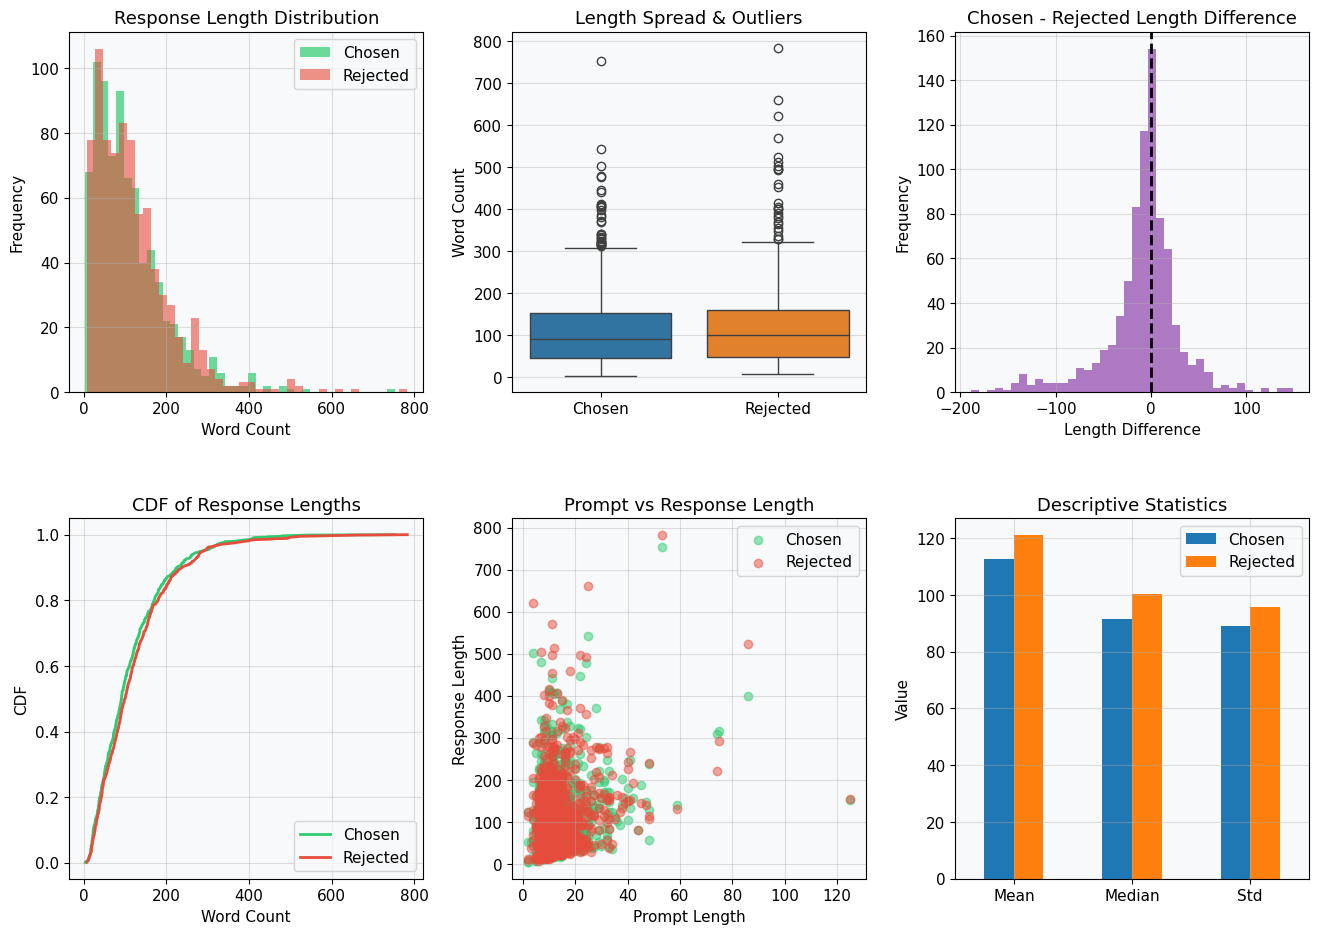


Descriptive Statistics:



,Chosen,Rejected
Mean,112.581250,120.951250
Median,91.500000,100.500000
Std,88.996915,95.797384


In [3]:
EDA_SIZE = 800
eda_sub  = raw_train.select(range(EDA_SIZE))

chosen_lens   = [len(ex["chosen"].split()) for ex in eda_sub]
rejected_lens = [len(ex["rejected"].split()) for ex in eda_sub]

len_diff = [c - r for c, r in zip(chosen_lens, rejected_lens)]

def get_prompt_len(text):
    parts = text.split("\n\nAssistant:")
    prompt = parts[0] if len(parts) > 0 else text
    return len(prompt.split())

prompt_lens = [get_prompt_len(ex["chosen"]) for ex in eda_sub]

fig = plt.figure(figsize=(16, 11))
gs  = gridspec.GridSpec(2, 3, hspace=0.35, wspace=0.25)

ax1 = fig.add_subplot(gs[0, 0])

ax1.hist(
    chosen_lens,
    bins=40,
    alpha=0.7,
    label="Chosen",
    color=COLORS["chosen"]
)

ax1.hist(
    rejected_lens,
    bins=40,
    alpha=0.6,
    label="Rejected",
    color=COLORS["rejected"]
)

ax1.set_title("Response Length Distribution")
ax1.set_xlabel("Word Count")
ax1.set_ylabel("Frequency")
ax1.legend()

ax2 = fig.add_subplot(gs[0, 1])

sns.boxplot(
    data=[chosen_lens, rejected_lens],
    ax=ax2
)

ax2.set_xticklabels(["Chosen", "Rejected"])
ax2.set_title("Length Spread & Outliers")
ax2.set_ylabel("Word Count")

ax3 = fig.add_subplot(gs[0, 2])

ax3.hist(
    len_diff,
    bins=40,
    color=COLORS["DPO"],
    alpha=0.8
)

ax3.axvline(0, color="black", linestyle="--")
ax3.set_title("Chosen - Rejected Length Difference")
ax3.set_xlabel("Length Difference")
ax3.set_ylabel("Frequency")

ax4 = fig.add_subplot(gs[1, 0])

sorted_chosen = np.sort(chosen_lens)
sorted_rejected = np.sort(rejected_lens)

cdf_chosen = np.arange(1, len(sorted_chosen)+1) / len(sorted_chosen)
cdf_rejected = np.arange(1, len(sorted_rejected)+1) / len(sorted_rejected)

ax4.plot(
    sorted_chosen,
    cdf_chosen,
    label="Chosen",
    color=COLORS["chosen"]
)

ax4.plot(
    sorted_rejected,
    cdf_rejected,
    label="Rejected",
    color=COLORS["rejected"]
)

ax4.set_title("CDF of Response Lengths")
ax4.set_xlabel("Word Count")
ax4.set_ylabel("CDF")
ax4.legend()

ax5 = fig.add_subplot(gs[1, 1])

ax5.scatter(
    prompt_lens,
    chosen_lens,
    alpha=0.5,
    label="Chosen",
    color=COLORS["chosen"]
)

ax5.scatter(
    prompt_lens,
    rejected_lens,
    alpha=0.5,
    label="Rejected",
    color=COLORS["rejected"]
)

ax5.set_title("Prompt vs Response Length")
ax5.set_xlabel("Prompt Length")
ax5.set_ylabel("Response Length")
ax5.legend()

ax6 = fig.add_subplot(gs[1, 2])

stats_df = pd.DataFrame({
    "Chosen": [
        np.mean(chosen_lens),
        np.median(chosen_lens),
        np.std(chosen_lens)
    ],
    "Rejected": [
        np.mean(rejected_lens),
        np.median(rejected_lens),
        np.std(rejected_lens)
    ]
}, index=["Mean", "Median", "Std"])

stats_df.plot(kind="bar", ax=ax6)

ax6.set_title("Descriptive Statistics")
ax6.set_ylabel("Value")
ax6.tick_params(axis='x', rotation=0)

plt.savefig("eda_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nDescriptive Statistics:\n")
display(stats_df)

Chart Analysis
 
**a)** Analyze the results shown in the charts below.

- The chosen and rejected responses have very similar distributions overall. 
- Also rejected responses are slightly longer on average! 
- The standard deviation is high for both groups, meaning response lengths vary a lot across samples.
- The boxplots confirm the presence of many outliers, with some responses reaching more than 700 words.
- The length-difference histogram is centered near zero, which means longer answers are not always preferred!
- The scatter plot shows a positive correlation between prompt length and response length(which means longer prompts usually produce longer answers)!


## Cell 3 — Tokenizer & Preprocessing

Load the tokenizer and define ChatML formatters (`make_chatml_prompt_only`, `make_chatml_full`). Then parse HH-RLHF into two DataFrames:
- **`sft_df`** — prompt + chosen response (for SFT)
- **`pref_df`** — prompt + chosen + rejected pairs (for RM / DPO / ORPO)

In [3]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.padding_side = "right"
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

SYSTEM_PROMPT = "You are a helpful, harmless, and honest assistant."

def parse_hh_rlhf(text, max_chars=350):
    if not isinstance(text, str) or not text.strip():
        return "", ""
    text = text.strip()
    marker = "\n\nAssistant:"
    if marker not in text:
        return "", ""
    prompt, response = text.rsplit(marker, 1)
    prompt = prompt.strip()
    response = response.strip()
    if not prompt or not response:
        return "", ""
    return prompt[:max_chars * 4], response[:max_chars * 4]

def _apply_chat_template(messages, add_generation_prompt=False):
    if getattr(tokenizer, "chat_template", None) is not None:
        return tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=add_generation_prompt,
        )
    out = []
    for m in messages:
        out.append(f"{m['role'].capitalize()}: {m['content'].strip()}")
    if add_generation_prompt:
        out.append("Assistant:")
    return "\n".join(out).strip()

def make_chatml_text(prompt, response):
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": prompt.strip()},
        {"role": "assistant", "content": response.strip()},
    ]
    return _apply_chat_template(messages, add_generation_prompt=False)

def make_chatml_prompt_only(prompt):
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": prompt.strip()},
    ]
    return _apply_chat_template(messages, add_generation_prompt=True)

sft_rows, pref_rows = [], []

for i in tqdm(range(N_TRAIN + N_EVAL), desc="Preprocessing"):
    ex = raw_train[i]

    p_ch, r_ch = parse_hh_rlhf(ex["chosen"])
    p_rj, r_rj = parse_hh_rlhf(ex["rejected"])

    if p_ch and r_ch:
        sft_rows.append({
            "text": make_chatml_text(p_ch, r_ch),
            "prompt": p_ch,
            "completion": r_ch,
        })

    if p_ch and r_ch and r_rj:
        prompt = p_ch
        pref_rows.append({
            "prompt": prompt,
            "chosen": r_ch,
            "rejected": r_rj,
            "prompt_text": make_chatml_prompt_only(prompt),
            "chosen_text": make_chatml_text(prompt, r_ch),
            "rejected_text": make_chatml_text(prompt, r_rj),
        })

sft_df  = pd.DataFrame(sft_rows).reset_index(drop=True)
pref_df = pd.DataFrame(pref_rows).reset_index(drop=True)

sft_cut  = min(len(sft_df), N_TRAIN + N_EVAL)
pref_cut = min(len(pref_df), N_TRAIN + N_EVAL)

sft_train_df  = sft_df.iloc[:min(N_TRAIN, len(sft_df))].reset_index(drop=True)
sft_eval_df   = sft_df.iloc[min(N_TRAIN, len(sft_df)):sft_cut].reset_index(drop=True)
pref_train_df = pref_df.iloc[:min(N_TRAIN, len(pref_df))].reset_index(drop=True)
pref_eval_df  = pref_df.iloc[min(N_TRAIN, len(pref_df)):pref_cut].reset_index(drop=True)

sft_train_hf  = Dataset.from_pandas(sft_train_df[["text"]], preserve_index=False)
sft_eval_hf   = Dataset.from_pandas(sft_eval_df[["text"]], preserve_index=False)
pref_train_hf = Dataset.from_pandas(pref_train_df, preserve_index=False)
pref_eval_hf  = Dataset.from_pandas(pref_eval_df, preserve_index=False)

print(f" SFT        — Train: {len(sft_train_hf)}  Eval: {len(sft_eval_hf)}")
print(f" Preference — Train: {len(pref_train_hf)}  Eval: {len(pref_eval_hf)}")

Preprocessing:   0%|          | 0/4500 [00:00<?, ?it/s]

 SFT        — Train: 4000  Eval: 499
 Preference — Train: 4000  Eval: 499


## Cell 4 — Base Model Setup

Load the pretrained base model and snapshot its weights as `BASE_MODEL_STATE`. Define `make_fresh_causal_lm()` to create a clean copy — reused at every training stage (SFT, RM, DPO, PPO).

In [5]:
_loader = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float32,
    low_cpu_mem_usage=True,
).to(DEVICE)

BASE_MODEL_STATE = {k: v.cpu().clone() for k, v in _loader.state_dict().items()}

print(f" Total parameters : {sum(p.numel() for p in _loader.parameters())/1e6:.1f}M")

del _loader
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()

def make_fresh_causal_lm(trainable=True):
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        torch_dtype=torch.float32,
        low_cpu_mem_usage=True,
    ).to(DEVICE)

    model.load_state_dict(BASE_MODEL_STATE, strict=True)
    model.config.pad_token_id = tokenizer.pad_token_id
    model.config.eos_token_id = tokenizer.eos_token_id
    model.config.use_cache = False

    if trainable:
        model.train()
        for p in model.parameters():
            p.requires_grad_(True)
    else:
        model.eval()
        for p in model.parameters():
            p.requires_grad_(False)

    return model

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

 Total parameters : 494.0M


In [6]:
import gc
import torch
def clear_torch_memory():
        gc.collect()
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

In [7]:
clear_torch_memory()
if "sft_model" in globals():
    del sft_model
if "sft_trainer" in globals():
    del sft_trainer

## Cell 5 — Supervised Fine-Tuning (SFT)

Fine-tune the base model on **chosen** prompt-completion pairs using `SFTTrainer` (TRL). After training, save weights to `SFT_STATE` (in memory) and `./qwen_sft_checkpoint` (on disk) — this checkpoint is the starting point for all downstream alignment stages (RM, DPO, PPO).

In [8]:
from trl import SFTTrainer, SFTConfig

sft_model = make_fresh_causal_lm(trainable=True)

grad_acc = 4 if DEVICE.type == "cuda" else 1

sft_config = SFTConfig(
    output_dir                  = "./qwen_sft_output",
    max_steps                   = STEPS_SFT,
    per_device_train_batch_size  = BATCH_SIZE,
    per_device_eval_batch_size   = BATCH_SIZE,
    gradient_accumulation_steps  = grad_acc,
    learning_rate                = LR_SFT,
    eval_strategy                = "steps",
    eval_steps                   = 10,
    logging_strategy             = "steps",
    logging_steps                = 10,
    save_strategy                = "steps",
    save_steps                   = 50,
    save_total_limit             = 1,
    report_to                    = "none",
    use_cpu                      = (DEVICE.type != "cuda"),
    #no_cuda                      = (DEVICE.type != "cuda"),
    max_length                   = MAX_LENGTH,
    dataset_text_field           = "text",
    remove_unused_columns        = True,
    bf16                         = False,
    fp16                         = (DEVICE.type == "cuda"),
    fp16_full_eval               = (DEVICE.type == "cuda"),
    gradient_checkpointing       = True,
    optim                        = "adamw_torch",
    seed                         = 42,
)

sft_trainer = SFTTrainer(
    model            = sft_model,
    args             = sft_config,
    train_dataset    = sft_train_hf,
    eval_dataset     = sft_eval_hf,
    processing_class = tokenizer,
)

sft_result = sft_trainer.train()

sft_losses      = [(h["step"], h["loss"]) for h in sft_trainer.state.log_history if "loss" in h]
sft_eval_losses = [(h["step"], h["eval_loss"]) for h in sft_trainer.state.log_history if "eval_loss" in h]

SFT_STATE = {k: v.cpu().clone() for k, v in sft_trainer.model.state_dict().items()}

save_dir = "./qwen_sft_checkpoint"
sft_trainer.model.save_pretrained(save_dir, safe_serialization=True)
tokenizer.save_pretrained(save_dir)


SFT_TRAINING_STATS = {
    "sft_losses": sft_losses,
    "sft_eval_losses": sft_eval_losses,
    "final_train_loss": sft_losses[-1][1] if len(sft_losses) else None,
    "final_eval_loss": sft_eval_losses[-1][1] if len(sft_eval_losses) else None,
    "best_eval_loss": min([x[1] for x in sft_eval_losses]) if len(sft_eval_losses) else None,
    "num_steps": len(sft_losses),
}

torch.save(SFT_TRAINING_STATS, "./sft_training_stats.pt")

print("SFT training completed and saved.")
print("Checkpoint saved to:", save_dir)
print("Stats saved to: ./sft_training_stats.pt")

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Adding EOS to train dataset:   0%|          | 0/4000 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/4000 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/499 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/499 [00:00<?, ? examples/s]

...

Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
10,2.196801,1.799311,1.915566,35067.000000,0.582633
20,1.789559,1.764712,1.745384,68436.000000,0.588631
30,1.788148,1.744206,1.773973,102305.000000,0.591530
40,1.795617,1.736316,1.750461,136826.000000,0.591667
50,1.780585,1.720782,1.738041,170394.000000,0.595711
60,1.743015,1.707999,1.717298,204724.000000,0.596073
70,1.732234,1.699953,1.699236,239098.000000,0.599131
80,1.734411,1.695030,1.756855,272942.000000,0.599083
90,1.734838,1.690086,1.713226,306647.000000,0.599647
100,1.732535,1.688031,1.708011,340636.000000,0.599964


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

SFT training completed and saved.
Checkpoint saved to: ./qwen_sft_checkpoint
Stats saved to: ./sft_training_stats.pt


In [ ]:
import shutil
shutil.rmtree("/kaggle/working/qwen_sft_output")
os.makedirs("/kaggle/working/qwen_sft_output")
shutil.rmtree("/kaggle/working/qwen_sft_checkpoint")
os.makedirs("/kaggle/working/qwen_sft_checkpoint")

## Cell 6 — SFT Results: Visualization & Sample Generation

Plot 3 charts from SFT training: **loss curve**, **smoothed moving average**, and **train vs eval loss** bar chart. Then generate a sample response from `sft_model` to qualitatively inspect output quality before alignment.

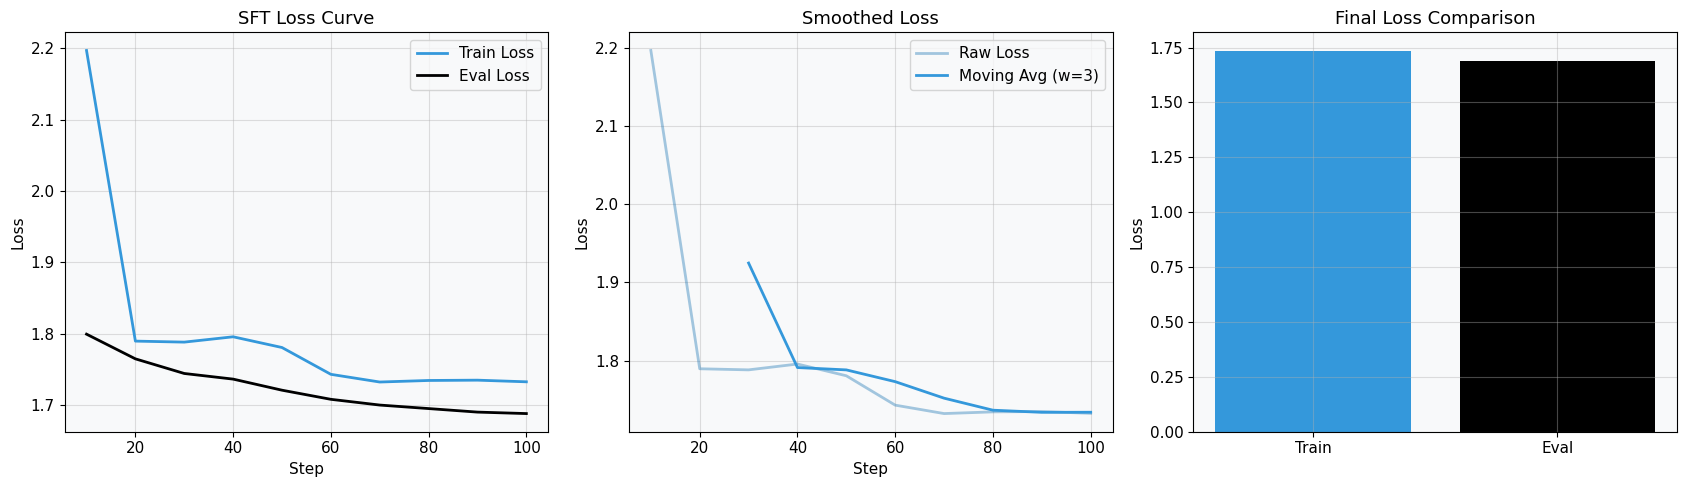

Prompt  : Human: what is the f word in spanish...
Response: The Spanish abbreviation for “f-word” is “fauci”.


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

steps = [s for s, _ in sft_losses]
loss_vals = [l for _, l in sft_losses]

if sft_losses:
    axes[0].plot(steps, loss_vals, label="Train Loss", color=COLORS["SFT"])

    if sft_eval_losses:
        ev_steps = [s for s, _ in sft_eval_losses]
        ev_loss  = [l for _, l in sft_eval_losses]
        axes[0].plot(ev_steps, ev_loss, label="Eval Loss", color="black")

    axes[0].set_title("SFT Loss Curve")
    axes[0].set_xlabel("Step")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

if sft_losses and len(sft_losses) > 3:
    axes[1].plot(steps, loss_vals, alpha=0.4, label="Raw Loss")

    w = max(3, len(loss_vals) // 5)
    sm = np.convolve(loss_vals, np.ones(w)/w, mode="valid")
    sm_steps = steps[w-1:]

    axes[1].plot(sm_steps, sm, label=f"Moving Avg (w={w})", color=COLORS["SFT"])

    axes[1].set_title("Smoothed Loss")
    axes[1].set_xlabel("Step")
    axes[1].set_ylabel("Loss")
    axes[1].legend()

if sft_losses and sft_eval_losses:
    final_train = loss_vals[-1]
    final_eval  = sft_eval_losses[-1][1]

    axes[2].bar(["Train", "Eval"], [final_train, final_eval],
                color=[COLORS["SFT"], "black"])

    axes[2].set_title("Final Loss Comparison")
    axes[2].set_ylabel("Loss")

plt.tight_layout()
plt.savefig("sft_results.png", dpi=150, bbox_inches="tight")
plt.show()

sample_q  = pref_eval_df.iloc[0]["prompt"][:150]
prompt_tx = make_chatml_prompt_only(sample_q)

tokenizer.padding_side = "left"
enc = tokenizer(prompt_tx, return_tensors="pt", max_length=100, truncation=True).to(DEVICE)
tokenizer.padding_side = "right"

sft_model.eval()
with torch.no_grad():
    gen = sft_model.generate(
        **enc,
        max_new_tokens=50,
        do_sample=True,
        temperature=0.8,
        top_p=0.9,
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )

input_len = enc["input_ids"].shape[1]
resp = tokenizer.decode(gen[0][input_len:], skip_special_tokens=True)

print(f"Prompt  : {sample_q[:100]}...")
print(f"Response: {resp[:250]}")

Chart Analysis
 
**a)** Analyze the results shown in the charts below.

- The SFT loss curves show a steady decrease in both training and evaluation loss.
- The smoothed curve confirms a stable downward trend with minor fluctuations.
- In the final comparison: eval loss is slightly lower than train loss. This may indicate mild underfitting (strong regularization effects can also be the reason).
- Overall the model learns steadily but not aggressively.
-  The sample output still shows a clear alignment failure! Because the model produces an incorrect and unsafe hallucination instead of a correct response!


In [ ]:
clear_torch_memory()
if "sft_model" in globals():
    del sft_model
if "sft_trainer" in globals():
    del sft_trainer

In [10]:
import shutil
shutil.rmtree("/kaggle/working/qwen_rm_checkpoint")
os.makedirs("/kaggle/working/qwen_rm_checkpoint")

## Cell 7 — Reward Model Training (Bradley-Terry)

Train a pairwise Reward Model using **Bradley-Terry loss**: `loss = -log σ(r_chosen − r_rejected)`. The model learns to score chosen responses higher than rejected ones.

Key implementation details:
- **Dynamic padding** per batch (no fixed-length waste)
- **L2 regularization** on reward scores to prevent saturation
- **Gradient accumulation** for stable updates on CPU

In [11]:
from torch.nn.utils.rnn import pad_sequence

if "sft_model" in globals():
    del sft_model
if "sft_trainer" in globals():
    del sft_trainer
torch.cuda.empty_cache()

RM_MAX_LEN = 96
RM_BATCH_SIZE = 1 if DEVICE.type == "cuda" else BATCH_SIZE
ACCUM_STEPS = 8 if DEVICE.type == "cuda" else 1

use_amp = False
scaler = None

tokenizer.truncation_side = "left"

if tokenizer.pad_token is None or tokenizer.pad_token == tokenizer.eos_token:
    tokenizer.add_special_tokens({"pad_token": "<|pad|>"})

tokenizer.pad_token_id = tokenizer.convert_tokens_to_ids(tokenizer.pad_token)

class PairwiseRewardDataset(TorchDataset):
    def __init__(self, df, tok, max_len):
        self.df = df.reset_index(drop=True)
        self.tok = tok

        self.c_enc = tok(
            self.df["chosen_text"].tolist(),
            truncation=True,
            max_length=max_len,
            padding=False,
        )

        self.r_enc = tok(
            self.df["rejected_text"].tolist(),
            truncation=True,
            max_length=max_len,
            padding=False,
        )

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        return {
            "c_ids": torch.tensor(self.c_enc["input_ids"][idx], dtype=torch.long),
            "c_mask": torch.tensor(self.c_enc["attention_mask"][idx], dtype=torch.long),
            "r_ids": torch.tensor(self.r_enc["input_ids"][idx], dtype=torch.long),
            "r_mask": torch.tensor(self.r_enc["attention_mask"][idx], dtype=torch.long),
        }

def dynamic_collate_fn(batch):
    return {
        "c_input_ids": pad_sequence(
            [x["c_ids"] for x in batch],
            batch_first=True,
            padding_value=tokenizer.pad_token_id,
        ),
        "c_attention_mask": pad_sequence(
            [x["c_mask"] for x in batch],
            batch_first=True,
            padding_value=0,
        ),
        "r_input_ids": pad_sequence(
            [x["r_ids"] for x in batch],
            batch_first=True,
            padding_value=tokenizer.pad_token_id,
        ),
        "r_attention_mask": pad_sequence(
            [x["r_mask"] for x in batch],
            batch_first=True,
            padding_value=0,
        ),
    }

def bradley_terry_loss(r_chosen, r_rejected, alpha=1e-4):
    diff = r_chosen - r_rejected
    bt = -F.logsigmoid(diff).mean()
    reg = alpha * diff.pow(2).mean()
    return bt + reg

reward_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=1,
    torch_dtype=torch.float32,
    low_cpu_mem_usage=True,
).to(DEVICE)

reward_model.config.pad_token_id = tokenizer.pad_token_id
reward_model.config.use_cache = False

if hasattr(reward_model, "gradient_checkpointing_enable"):
    reward_model.gradient_checkpointing_enable()

if len(tokenizer) != reward_model.get_input_embeddings().num_embeddings:
    reward_model.resize_token_embeddings(len(tokenizer))

with torch.no_grad():
    if hasattr(reward_model, "score"):
        reward_model.score.weight.normal_(mean=0.0, std=0.02)
        if reward_model.score.bias is not None:
            reward_model.score.bias.zero_()
    elif hasattr(reward_model, "classifier"):
        reward_model.classifier.weight.normal_(mean=0.0, std=0.02)
        if reward_model.classifier.bias is not None:
            reward_model.classifier.bias.zero_()

rm_train_ds = PairwiseRewardDataset(pref_train_df, tokenizer, RM_MAX_LEN)
rm_eval_ds  = PairwiseRewardDataset(pref_eval_df, tokenizer, RM_MAX_LEN)

rm_train_ldr = DataLoader(
    rm_train_ds,
    batch_size=RM_BATCH_SIZE,
    shuffle=True,
    collate_fn=dynamic_collate_fn,
)

rm_eval_ldr = DataLoader(
    rm_eval_ds,
    batch_size=RM_BATCH_SIZE,
    shuffle=False,
    collate_fn=dynamic_collate_fn,
)

rm_optimizer = AdamW(reward_model.parameters(), lr=LR_RM)

total_steps = max(1, (STEPS_RM + ACCUM_STEPS - 1) // ACCUM_STEPS)
warmup_steps = max(1, int(0.1 * total_steps))

rm_scheduler = get_linear_schedule_with_warmup(
    rm_optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

rm_train_losses, rm_eval_losses, rm_eval_accs = [], [], []

reward_model.train()
rm_optimizer.zero_grad(set_to_none=True)

train_iter = iter(rm_train_ldr)

for step in tqdm(range(STEPS_RM), desc="RM Training"):

    try:
        batch = next(train_iter)
    except StopIteration:
        train_iter = iter(rm_train_ldr)
        batch = next(train_iter)

    for k in batch:
        batch[k] = batch[k].to(DEVICE, non_blocking=True)

    r_c = reward_model(
        input_ids=batch["c_input_ids"],
        attention_mask=batch["c_attention_mask"],
    ).logits.view(-1)

    r_r = reward_model(
        input_ids=batch["r_input_ids"],
        attention_mask=batch["r_attention_mask"],
    ).logits.view(-1)

    loss = bradley_terry_loss(r_c, r_r) / ACCUM_STEPS

    loss.backward()

    rm_train_losses.append((step + 1, float(loss.item()) * ACCUM_STEPS))

    if (step + 1) % ACCUM_STEPS == 0 or (step + 1) == STEPS_RM:
        torch.nn.utils.clip_grad_norm_(reward_model.parameters(), 1.0)

        rm_optimizer.step()
        rm_scheduler.step()
        rm_optimizer.zero_grad(set_to_none=True)

    if (step + 1) % 10 == 0:
        reward_model.eval()

        eval_loss_sum = 0.0
        eval_correct = 0
        eval_total = 0

        with torch.no_grad():
            for eb in rm_eval_ldr:
                for k in eb:
                    eb[k] = eb[k].to(DEVICE)

                er_c = reward_model(
                    input_ids=eb["c_input_ids"],
                    attention_mask=eb["c_attention_mask"],
                ).logits.view(-1)

                er_r = reward_model(
                    input_ids=eb["r_input_ids"],
                    attention_mask=eb["r_attention_mask"],
                ).logits.view(-1)

                ev_loss = bradley_terry_loss(er_c, er_r)

                eval_loss_sum += float(ev_loss.item())
                eval_correct += (er_c > er_r).sum().item()
                eval_total += er_c.numel()

        avg_eval_loss = eval_loss_sum / max(1, len(rm_eval_ldr))
        eval_acc = eval_correct / max(1, eval_total)

        rm_eval_losses.append((step + 1, avg_eval_loss))
        rm_eval_accs.append((step + 1, eval_acc))

        print(
            f"Step {step + 1:>4} | eval_loss={avg_eval_loss:.4f} | pairwise_acc={eval_acc:.4f}"
        )

        reward_model.train()


RM_STATE = {k: v.cpu().clone() for k, v in reward_model.state_dict().items()}

rm_save_dir = "./qwen_rm_checkpoint"
reward_model.save_pretrained(rm_save_dir, safe_serialization=True)
tokenizer.save_pretrained(rm_save_dir)

RM_RESULTS = {

    "rm_train_losses": rm_train_losses,
    "rm_eval_losses": rm_eval_losses,
    "rm_eval_accs": rm_eval_accs,

    "final_train_loss":
        rm_train_losses[-1][1]
        if len(rm_train_losses) else None,

    "final_eval_loss":
        rm_eval_losses[-1][1]
        if len(rm_eval_losses) else None,

    "final_eval_acc":
        rm_eval_accs[-1][1]
        if len(rm_eval_accs) else None,

    "mean_train_loss":
        float(
            np.mean(
                [x[1] for x in rm_train_losses]
            )
        ) if len(rm_train_losses) else None,

    "mean_eval_loss":
        float(
            np.mean(
                [x[1] for x in rm_eval_losses]
            )
        ) if len(rm_eval_losses) else None,

    "mean_eval_acc":
        float(
            np.mean(
                [x[1] for x in rm_eval_accs]
            )
        ) if len(rm_eval_accs) else None,
}

torch.save(
    RM_RESULTS,
    "./rm_training_stats.pt"
)

print(f"\nReward model saved to: {rm_save_dir}")
print("RM stats saved to: ./rm_training_stats.pt")



Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Qwen2ForSequenceClassification LOAD REPORT from: Qwen/Qwen2.5-0.5B-Instruct
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RM Training:   0%|          | 0/100 [00:00<?, ?it/s]

Step   10 | eval_loss=1.2268 | pairwise_acc=0.5050
Step   20 | eval_loss=1.8831 | pairwise_acc=0.5611
Step   30 | eval_loss=1.9580 | pairwise_acc=0.5210
Step   40 | eval_loss=1.0756 | pairwise_acc=0.5551
Step   50 | eval_loss=0.9697 | pairwise_acc=0.5691
Step   60 | eval_loss=0.8847 | pairwise_acc=0.5731
Step   70 | eval_loss=0.9140 | pairwise_acc=0.5511
Step   80 | eval_loss=0.9572 | pairwise_acc=0.5230
Step   90 | eval_loss=0.9841 | pairwise_acc=0.5190
Step  100 | eval_loss=1.0074 | pairwise_acc=0.5291


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Reward model saved to: ./qwen_rm_checkpoint
RM stats saved to: ./rm_training_stats.pt


## Cell 8 — Reward Model Results & get_reward()

Plot 3 charts: **BT loss curve**, **pairwise accuracy** over training, and **reward score distribution** (chosen vs rejected) on the eval set. Then define `get_reward()` — the reward signal for PPO — which returns a raw logit score for any ChatML-formatted text.

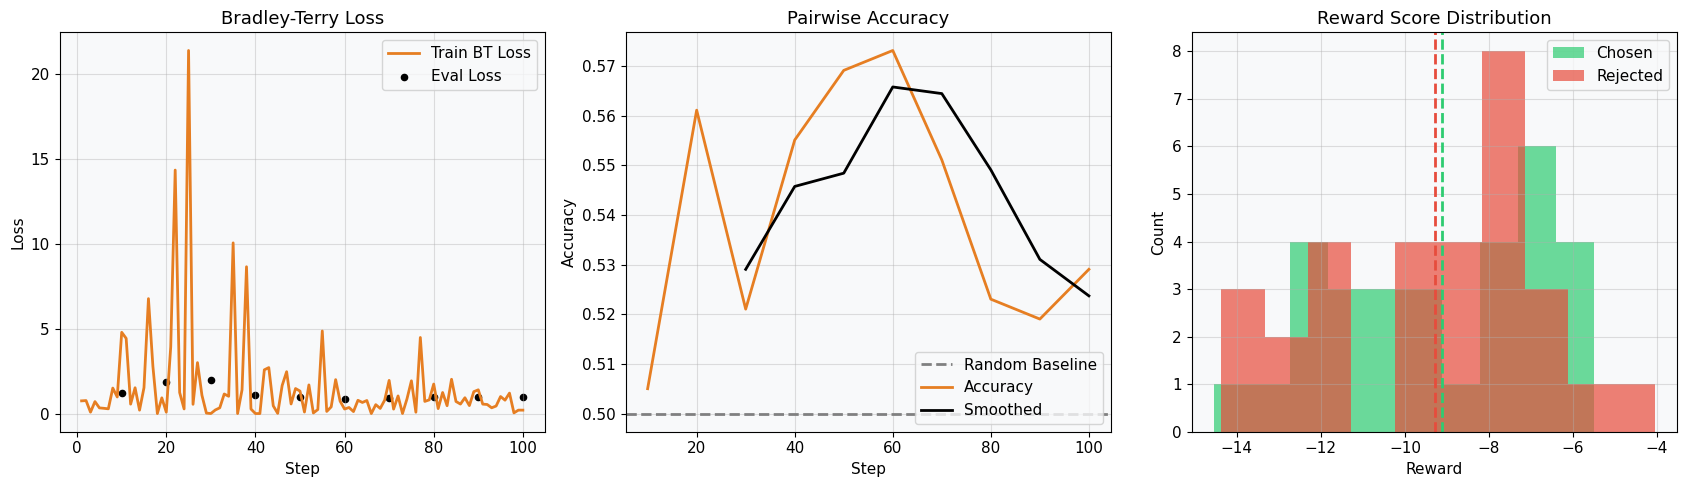

 Mean reward — Chosen  : -9.1187
 Mean reward — Rejected: -9.2757
 Pairwise Accuracy     : 40.00%
 Demo chosen  : -8.4143
 Demo rejected: -7.7787


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

rm_steps = [s for s, _ in rm_train_losses]
rm_loss  = [l for _, l in rm_train_losses]

if rm_train_losses:
    axes[0].plot(rm_steps, rm_loss, label="Train BT Loss", color=COLORS["RM"])

if rm_eval_losses:
    ev_steps = [s for s, _ in rm_eval_losses]
    ev_loss  = [l for _, l in rm_eval_losses]
    axes[0].scatter(ev_steps, ev_loss, label="Eval Loss", color="black", s=20)

axes[0].set_title("Bradley-Terry Loss")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].axhline(0.5, linestyle="--", color="gray", label="Random Baseline")

if rm_eval_accs:
    acc_steps = [s for s, _ in rm_eval_accs]
    acc_vals  = [a for _, a in rm_eval_accs]

    axes[1].plot(acc_steps, acc_vals, label="Accuracy", color=COLORS["RM"])

    w_rm = max(3, len(acc_vals) // 5)
    sm   = np.convolve(acc_vals, np.ones(w_rm) / w_rm, mode="valid")
    sm_steps = acc_steps[w_rm - 1:]

    axes[1].plot(sm_steps, sm, label="Smoothed", color="black")

axes[1].set_title("Pairwise Accuracy")
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

eval_c_rewards, eval_r_rewards = [], []

reward_model.eval()
with torch.no_grad():
    for i in range(min(30, len(pref_eval_df))):
        row = pref_eval_df.iloc[i]

        enc_c = tokenizer(
            row["chosen_text"],
            return_tensors="pt",
            truncation=True,
            max_length=MAX_LENGTH,
        ).to(DEVICE)

        enc_r = tokenizer(
            row["rejected_text"],
            return_tensors="pt",
            truncation=True,
            max_length=MAX_LENGTH,
        ).to(DEVICE)

        eval_c_rewards.append(reward_model(**enc_c).logits.squeeze().item())
        eval_r_rewards.append(reward_model(**enc_r).logits.squeeze().item())

axes[2].hist(eval_c_rewards, alpha=0.7, label="Chosen", color=COLORS["chosen"], bins=10)
axes[2].hist(eval_r_rewards, alpha=0.7, label="Rejected", color=COLORS["rejected"], bins=10)

axes[2].axvline(np.mean(eval_c_rewards), color=COLORS["chosen"], linestyle="--")
axes[2].axvline(np.mean(eval_r_rewards), color=COLORS["rejected"], linestyle="--")

axes[2].set_title("Reward Score Distribution")
axes[2].set_xlabel("Reward")
axes[2].set_ylabel("Count")
axes[2].legend()

plt.tight_layout()
plt.savefig("rm_results.png", dpi=150, bbox_inches="tight")
plt.show()

pa = np.mean([c > r for c, r in zip(eval_c_rewards, eval_r_rewards)])

print(f" Mean reward — Chosen  : {np.mean(eval_c_rewards):.4f}")
print(f" Mean reward — Rejected: {np.mean(eval_r_rewards):.4f}")
print(f" Pairwise Accuracy     : {pa:.2%}")

def get_reward(chatml_text):
    reward_model.eval()
    with torch.no_grad():
        enc = tokenizer(
            chatml_text,
            return_tensors="pt",
            truncation=True,
            max_length=MAX_LENGTH,
        ).to(DEVICE)

        score = reward_model(**enc).logits.squeeze(-1).item()

    return float(score)

print(f" Demo chosen  : {get_reward(pref_eval_df.iloc[0]['chosen_text']):.4f}")
print(f" Demo rejected: {get_reward(pref_eval_df.iloc[0]['rejected_text']):.4f}")

Chart Analysis
 
**a)** Analyze the results shown in the charts below.

- The reward model learns weakly. 
- The loss is very noisy. With large spikes. So training is not stable.
-  Accuracy stays only a little above random and ends low. 
-  Chosen and rejected rewards are very closeand 
-  Final pairwise accuracy is only $40\%$ which means the model does not separate preferences well!


In [13]:
clear_torch_memory()

In [14]:
import shutil
shutil.rmtree("/kaggle/working/qwen_ppo_checkpoint")
os.makedirs("/kaggle/working/qwen_ppo_checkpoint")

## Cell 9 — PPO Training

Fine-tune the SFT model using **PPO** with the Reward Model as reward signal. Key components:

- **Clipped objective** — `clip(r_t, 1−ε, 1+ε)` prevents large policy updates
- **KL penalty** — keeps policy close to the frozen SFT reference
- **EMA baseline** — reduces variance in advantage estimation

In [ ]:
os._exit(0)

In [4]:
import torch
from transformers import AutoModelForSequenceClassification

reward_model = AutoModelForSequenceClassification.from_pretrained(
    "./qwen_rm_checkpoint",
    torch_dtype=DTYPE,
    trust_remote_code=True
).to(DEVICE)

reward_model.eval()

for param in reward_model.parameters():
    param.requires_grad = False


def get_reward(text):

    enc = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH,
        padding=False
    ).to(DEVICE)

    with torch.no_grad():
        reward = reward_model(
            input_ids=enc["input_ids"],
            attention_mask=enc["attention_mask"]
        ).logits.squeeze(-1)

    return reward.item()


print("Reward model loaded!")

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Reward model loaded!


In [5]:
import torch
import torch.nn.functional as F
import numpy as np

from transformers import (
    AutoModelForCausalLM,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW
from tqdm import tqdm


ppo_policy = AutoModelForCausalLM.from_pretrained(
    "./qwen_sft_checkpoint",
    torch_dtype=DTYPE,
    trust_remote_code=True
).to(DEVICE)

ppo_policy.train()
ppo_policy.gradient_checkpointing_enable()


ppo_ref = AutoModelForCausalLM.from_pretrained(
    "./qwen_sft_checkpoint",
    torch_dtype=DTYPE,
    trust_remote_code=True
).to(DEVICE)

ppo_ref.eval()

# Freeze reference model
for param in ppo_ref.parameters():
    param.requires_grad = False


use_scaler = False
scaler_ppo = None


ppo_optimizer = AdamW(
    ppo_policy.parameters(),
    lr=LR_PPO,
    weight_decay=0.01
)

ppo_scheduler = get_linear_schedule_with_warmup(
    ppo_optimizer,
    num_warmup_steps=max(5, STEPS_PPO // 20),
    num_training_steps=STEPS_PPO
)


CLIP_EPS = 0.2
MAX_KL = 2.0
EMA_ALPHA = 0.05


def get_response_log_probs(
    model,
    input_ids,
    response_mask
):

    outputs = model(
        input_ids=input_ids,
        use_cache=False
    )

    logits = outputs.logits

    shift_logits = logits[:, :-1]
    shift_labels = input_ids[:, 1:]
    shift_mask = response_mask[:, 1:].float()

    log_probs = F.log_softmax(
        shift_logits,
        dim=-1
    )

    token_log_probs = log_probs.gather(
        dim=-1,
        index=shift_labels.unsqueeze(-1)
    ).squeeze(-1)

    token_log_probs = (
        token_log_probs * shift_mask
    )

    return token_log_probs.sum(dim=-1)


def compute_kl_with_grad(
    policy_logits,
    ref_logits,
    response_mask
):

    policy_log_probs = F.log_softmax(
        policy_logits[:, :-1],
        dim=-1
    )

    ref_log_probs = F.log_softmax(
        ref_logits[:, :-1].detach(),
        dim=-1
    )

    policy_probs = policy_log_probs.exp()

    token_kl = (
        policy_probs *
        (policy_log_probs - ref_log_probs)
    ).sum(dim=-1)

    shift_mask = response_mask[:, 1:].float()

    token_kl = token_kl * shift_mask

    denom = shift_mask.sum().clamp(min=1)

    return token_kl.sum() / denom


ppo_prompts = (
    sft_train_df["prompt"]
    .dropna()
    .astype(str)
    .tolist()
)

reward_baseline = 0.5


ppo_reward_hist = []
ppo_kl_hist = []
ppo_pg_hist = []
ppo_total_hist = []


tokenizer.padding_side = "left"

print(f"\nTraining PPO ({STEPS_PPO} steps)...")

for step in tqdm(
    range(STEPS_PPO),
    desc="PPO Training"
):

    prompt_tx = ppo_prompts[
        step % len(ppo_prompts)
    ]

    enc = tokenizer(
        prompt_tx,
        return_tensors="pt",
        max_length=80,
        truncation=True,
        padding=False
    ).to(DEVICE)

    prompt_len = (
        enc["input_ids"].shape[1]
    )

    ppo_policy.eval()

    with torch.no_grad():

        gen = ppo_policy.generate(
            **enc,
            max_new_tokens=30,
            do_sample=True,
            temperature=1.0,
            top_p=0.95,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
            use_cache=True
        )

    resp_text = tokenizer.decode(
        gen[0][prompt_len:],
        skip_special_tokens=True
    )

    if not resp_text.strip():
        continue

    response_mask = torch.zeros_like(gen)
    response_mask[:, prompt_len:] = 1

    with torch.no_grad():

        old_log_prob = (
            get_response_log_probs(
                ppo_policy,
                gen,
                response_mask
            )
        )

        ref_logits = ppo_ref(
            input_ids=gen,
            attention_mask=torch.ones_like(gen),
            use_cache=False
        ).logits

    ppo_policy.train()

    reward_val = get_reward(resp_text)

    advantage = (
        reward_val -
        reward_baseline
    )

    reward_baseline = (
        (1 - EMA_ALPHA)
        * reward_baseline
        +
        EMA_ALPHA
        * reward_val
    )

    adv_t = torch.tensor(
        advantage,
        dtype=torch.float32,
        device=DEVICE
    )

    def compute_loss():

        outputs = ppo_policy(
            input_ids=gen,
            attention_mask=torch.ones_like(gen),
            use_cache=False
        )

        policy_logits = outputs.logits

        new_log_prob = (
            get_response_log_probs(
                ppo_policy,
                gen,
                response_mask
            )
        )

        ratio = torch.exp(
            new_log_prob -
            old_log_prob
        )

        clipped_ratio = torch.clamp(
            ratio,
            1.0 - CLIP_EPS,
            1.0 + CLIP_EPS
        )

        pg_loss_1 = ratio * adv_t
        pg_loss_2 = clipped_ratio * adv_t

        ppo_loss = -torch.min(
            pg_loss_1,
            pg_loss_2
        ).mean()

        kl_tensor = (
            compute_kl_with_grad(
                policy_logits,
                ref_logits,
                response_mask
            )
        )

        total_loss = (
            ppo_loss +
            KL_COEF * kl_tensor
        )

        return (
            total_loss,
            kl_tensor
        )

    with torch.no_grad():

        logits_check = ppo_policy(
            input_ids=gen,
            attention_mask=torch.ones_like(gen),
            use_cache=False
        ).logits

        kl_check = (
            compute_kl_with_grad(
                logits_check,
                ref_logits,
                response_mask
            ).item()
        )

    if kl_check > MAX_KL:
        continue

    total_loss, kl_tensor = (
        compute_loss()
    )

    ppo_optimizer.zero_grad()

    total_loss.backward()

    torch.nn.utils.clip_grad_norm_(
        ppo_policy.parameters(),
        max_norm=1.0
    )

    ppo_optimizer.step()
    ppo_scheduler.step()

    ppo_reward_hist.append(
        reward_val
    )

    ppo_kl_hist.append(
        kl_tensor.item()
    )

    ppo_pg_hist.append(
        total_loss.item()
    )

    ppo_total_hist.append(
        reward_val -
        KL_COEF * kl_tensor.item()
    )

    if (step + 1) % 10 == 0:
        print(
            f"Step {step+1} | "
            f"Reward={reward_val:.3f} | "
            f"KL={kl_tensor.item():.4f} | "
            f"Loss={total_loss.item():.4f}"
        )


tokenizer.padding_side = "right"
ppo_policy.eval()


save_dir = "./qwen_ppo_checkpoint"

ppo_policy.save_pretrained(save_dir)
tokenizer.save_pretrained(save_dir)


PPO_RESULTS = {
    "ppo_reward_hist": ppo_reward_hist,
    "ppo_kl_hist": ppo_kl_hist,
    "ppo_pg_hist": ppo_pg_hist,
    "ppo_total_hist": ppo_total_hist,

    "mean_reward":
        float(np.mean(ppo_reward_hist))
        if len(ppo_reward_hist) else None,

    "mean_kl":
        float(np.mean(ppo_kl_hist))
        if len(ppo_kl_hist) else None,

    "final_loss":
        ppo_pg_hist[-1]
        if len(ppo_pg_hist) else None
}

torch.save(
    PPO_RESULTS,
    "./ppo_training_stats.pt"
)

print("\nPPO Training Completed!")
print(f"PPO model saved to: {save_dir}")
print("PPO stats saved to: ./ppo_training_stats.pt")

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]


Training PPO (100 steps)...


PPO Training:  10%|█         | 10/100 [00:19<02:55,  1.95s/it]

Step 10 | Reward=-3.172 | KL=0.0022 | Loss=1.8514


...

Step 90 | Reward=-1.609 | KL=0.0008 | Loss=-1.7467


PPO Training: 100%|██████████| 100/100 [03:09<00:00,  1.90s/it]

Step 100 | Reward=-5.750 | KL=0.0012 | Loss=1.0475


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


PPO Training Completed!
PPO model saved to: ./qwen_ppo_checkpoint
PPO stats saved to: ./ppo_training_stats.pt


## Cell 10 — PPO Results: Visualization & Analysis

Plot 3 charts: **reward curve** vs baseline (0.5), **KL divergence** over training, and a **reward–KL tradeoff scatter** colored by step. Then print key stats (mean reward, % above baseline, mean KL) to evaluate whether the policy improved without drifting too far from the SFT reference.

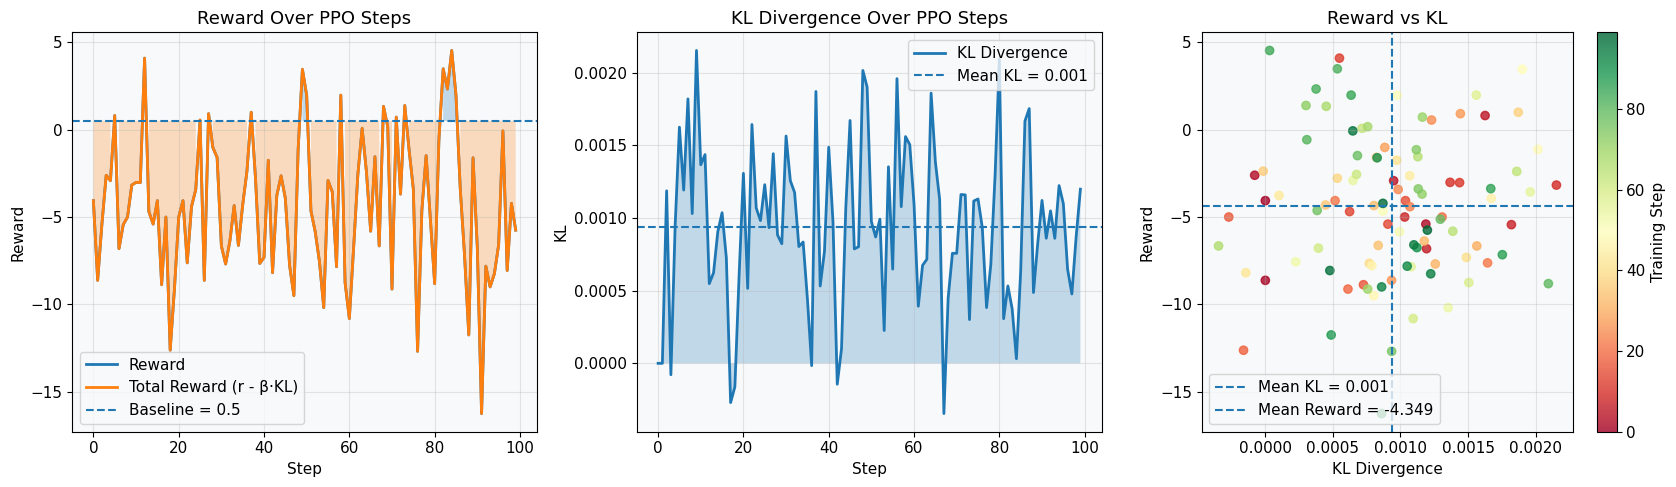

Mean Reward       : -4.3486
Mean KL           : 0.0009
Mean Total Reward : -4.3486
Reward trend      : ↓ declining
% steps above 0.5 : 15.0%


In [6]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(17, 5))



steps_reward = range(len(ppo_reward_hist))

axes[0].plot(
    ppo_reward_hist,
    label="Reward",
    linewidth=2
)

axes[0].plot(
    ppo_total_hist,
    label="Total Reward (r - β·KL)",
    linewidth=2
)

axes[0].axhline(
    0.5,
    linestyle="--",
    linewidth=1.5,
    label="Baseline = 0.5"
)

axes[0].fill_between(
    steps_reward,
    0.5,
    ppo_reward_hist,
    where=[r > 0.5 for r in ppo_reward_hist],
    alpha=0.25
)

# Red below baseline
axes[0].fill_between(
    steps_reward,
    0.5,
    ppo_reward_hist,
    where=[r <= 0.5 for r in ppo_reward_hist],
    alpha=0.25
)

axes[0].set_title("Reward Over PPO Steps")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Reward")
axes[0].grid(True, alpha=0.3)
axes[0].legend()



steps_kl = range(len(ppo_kl_hist))

axes[1].plot(
    ppo_kl_hist,
    linewidth=2,
    label="KL Divergence"
)

axes[1].fill_between(
    steps_kl,
    ppo_kl_hist,
    alpha=0.25
)

axes[1].axhline(
    np.mean(ppo_kl_hist),
    linestyle="--",
    linewidth=1.5,
    label=f"Mean KL = {np.mean(ppo_kl_hist):.3f}"
)

axes[1].set_title("KL Divergence Over PPO Steps")
axes[1].set_xlabel("Step")
axes[1].set_ylabel("KL")
axes[1].grid(True, alpha=0.3)
axes[1].legend()



sc = axes[2].scatter(
    ppo_kl_hist,
    ppo_reward_hist,
    c=range(len(ppo_kl_hist)),
    cmap="RdYlGn",
    alpha=0.8
)

plt.colorbar(
    sc,
    ax=axes[2],
    label="Training Step"
)

axes[2].axvline(
    np.mean(ppo_kl_hist),
    linestyle="--",
    linewidth=1.5,
    label=f"Mean KL = {np.mean(ppo_kl_hist):.3f}"
)

axes[2].axhline(
    np.mean(ppo_reward_hist),
    linestyle="--",
    linewidth=1.5,
    label=f"Mean Reward = {np.mean(ppo_reward_hist):.3f}"
)

axes[2].set_title("Reward vs KL")
axes[2].set_xlabel("KL Divergence")
axes[2].set_ylabel("Reward")
axes[2].grid(True, alpha=0.3)
axes[2].legend()



plt.tight_layout()
plt.savefig(
    "ppo_results.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()



print(f"Mean Reward       : {np.mean(ppo_reward_hist):.4f}")
print(f"Mean KL           : {np.mean(ppo_kl_hist):.4f}")
print(f"Mean Total Reward : {np.mean(ppo_total_hist):.4f}")

# Reward trend
print(
    f"Reward trend      : "
    f"{'↑ improving' if ppo_reward_hist[-1] > ppo_reward_hist[0] else '↓ declining'}"
)

# Percentage above baseline
print(
    f"% steps above 0.5 : "
    f"{np.mean(np.array(ppo_reward_hist) > 0.5) * 100:.1f}%"
)

Chart Analysis
 
**a)** Analyze the results shown in the charts below.

- PPO training shows high instability with no clear improvement in rewards.
- The reward goes up and down a lot. It does not get better over time(whithout converging). 
- It gets rewards that are often negative. 
- The KL divergence is small but also goes up and down. 
- The model is not improving. It does not learn well.


In [7]:
import shutil
shutil.rmtree("/kaggle/working/qwen_dpo_checkpoint")
os.makedirs("/kaggle/working/qwen_dpo_checkpoint")

## Cell 11 — DPO Training

Train `dpo_policy` to prefer chosen over rejected responses using a frozen `dpo_ref` — no reward model needed.

**Implement:**
- `encode_with_response_mask()` — tokenize `prompt + response`, build a binary mask that is **1 only on response tokens**
- `compute_response_logprob()` — shift logits/labels by 1, gather token log-probs, sum over response mask
- `dpo_loss_fn()` — compute `loss = -log σ(β · [(log π_θ(y_w) − log π_ref(y_w)) − (log π_θ(y_l) − log π_ref(y_l))])`; ref runs inside `no_grad()`
- **Training loop** — accumulate gradients every `GRAD_ACCUM=4` steps, then clip (`max_norm=1.0`) → optimizer → scheduler

> Watch the **margin** (`r_chosen − r_rejected`): it should grow over training.

In [8]:
import torch
import torch.nn.functional as F
import random
import numpy as np
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from tqdm import tqdm

GRAD_ACCUM = 4
beta = BETA_DPO if "BETA_DPO" in globals() else 0.1

dpo_policy = AutoModelForCausalLM.from_pretrained(
    "./qwen_sft_checkpoint",
    torch_dtype=DTYPE,
    trust_remote_code=True,
).to(DEVICE)

dpo_policy.train()

dpo_ref = AutoModelForCausalLM.from_pretrained(
    "./qwen_sft_checkpoint",
    torch_dtype=DTYPE,
    trust_remote_code=True,
).to(DEVICE)

dpo_ref.eval()
for p in dpo_ref.parameters():
    p.requires_grad = False

tokenizer = AutoTokenizer.from_pretrained("./qwen_sft_checkpoint", trust_remote_code=True)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

tokenizer.padding_side = "right"

dpo_optimizer = AdamW(dpo_policy.parameters(), lr=LR_DPO, weight_decay=0.01)

dpo_scheduler = get_linear_schedule_with_warmup(
    dpo_optimizer,
    num_warmup_steps=10,
    num_training_steps=max(1, STEPS_DPO // GRAD_ACCUM),
)

def encode_with_response_mask(prompt_text, full_text, tokenizer, max_length):

    prompt_ids = tokenizer(
        prompt_text,
        truncation=True,
        max_length=max_length,
        return_tensors="pt",
    )

    full_enc = tokenizer(
        full_text,
        truncation=True,
        max_length=max_length,
        return_tensors="pt",
    )

    prompt_len = prompt_ids["input_ids"].shape[1]
    seq_len = full_enc["input_ids"].shape[1]

    response_mask = torch.zeros((1, seq_len), dtype=torch.long)
    start = min(prompt_len, seq_len)
    response_mask[:, start:] = 1

    return (
        full_enc["input_ids"],
        full_enc["attention_mask"],
        response_mask,
    )

def compute_response_logprob(model, input_ids, attention_mask, response_mask):

    out = model(input_ids=input_ids, attention_mask=attention_mask, use_cache=False)
    logits = out.logits

    shift_logits = logits[:, :-1, :]
    shift_labels = input_ids[:, 1:]
    shift_mask = response_mask[:, 1:].float()

    log_probs = F.log_softmax(shift_logits, dim=-1)

    token_logp = log_probs.gather(
        dim=-1,
        index=shift_labels.unsqueeze(-1)
    ).squeeze(-1)

    token_logp = token_logp * shift_mask

    return token_logp.sum(dim=-1)

def dpo_loss_fn(
    policy, ref,
    c_ids, c_mask, c_rmask,
    r_ids, r_mask, r_rmask,
    beta
):

    pi_c = compute_response_logprob(policy, c_ids, c_mask, c_rmask)
    pi_r = compute_response_logprob(policy, r_ids, r_mask, r_rmask)

    with torch.no_grad():
        ref_c = compute_response_logprob(ref, c_ids, c_mask, c_rmask)
        ref_r = compute_response_logprob(ref, r_ids, r_mask, r_rmask)

    r_chosen   = beta * (pi_c - ref_c)
    r_rejected = beta * (pi_r - ref_r)

    margin = r_chosen - r_rejected

    loss = -F.logsigmoid(margin).mean()

    return loss, r_chosen.mean(), r_rejected.mean(), margin.mean()

dpo_loss_hist, dpo_chosen_hist, dpo_rejected_hist, dpo_margin_hist = [], [], [], []

print(f"\nTraining DPO ({STEPS_DPO} steps, grad_accum={GRAD_ACCUM}) ...")

dpo_optimizer.zero_grad()

accum_loss = accum_cr = accum_rr = accum_margin = 0.0
update_count = 0

indices = list(range(len(pref_train_df)))

for step in tqdm(range(STEPS_DPO), desc="DPO Training"):

    random.shuffle(indices)
    idx = indices[step % len(indices)]
    row = pref_train_df.iloc[idx]

    prompt_text = row.get("prompt_text", row.get("prompt", ""))

    c_ids, c_mask, c_rmask = encode_with_response_mask(
        prompt_text, row["chosen_text"], tokenizer, MAX_LENGTH
    )
    r_ids, r_mask, r_rmask = encode_with_response_mask(
        prompt_text, row["rejected_text"], tokenizer, MAX_LENGTH
    )

    c_ids, c_mask, c_rmask = c_ids.to(DEVICE), c_mask.to(DEVICE), c_rmask.to(DEVICE)
    r_ids, r_mask, r_rmask = r_ids.to(DEVICE), r_mask.to(DEVICE), r_rmask.to(DEVICE)

    if USE_AMP:
        with torch.cuda.amp.autocast(dtype=DTYPE):
            loss, cr, rr, margin = dpo_loss_fn(
                dpo_policy, dpo_ref,
                c_ids, c_mask, c_rmask,
                r_ids, r_mask, r_rmask,
                beta,
            )
        loss = loss / GRAD_ACCUM
    else:
        loss, cr, rr, margin = dpo_loss_fn(
            dpo_policy, dpo_ref,
            c_ids, c_mask, c_rmask,
            r_ids, r_mask, r_rmask,
            beta,
        )
        loss = loss / GRAD_ACCUM

    loss.backward()

    accum_loss += loss.item()
    accum_cr += cr.item()
    accum_rr += rr.item()
    accum_margin += margin.item()

    if (step + 1) % GRAD_ACCUM == 0:

        torch.nn.utils.clip_grad_norm_(dpo_policy.parameters(), 1.0)

        dpo_optimizer.step()
        dpo_scheduler.step()
        dpo_optimizer.zero_grad()

        update_count += 1

        avg_loss = accum_loss
        avg_cr = accum_cr / GRAD_ACCUM
        avg_rr = accum_rr / GRAD_ACCUM
        avg_margin = accum_margin / GRAD_ACCUM

        dpo_loss_hist.append(avg_loss)
        dpo_chosen_hist.append(avg_cr)
        dpo_rejected_hist.append(avg_rr)
        dpo_margin_hist.append(avg_margin)

        accum_loss = accum_cr = accum_rr = accum_margin = 0.0

        if update_count % 10 == 0:
            print(
                f"Update {update_count} | "
                f"Loss={avg_loss:.4f} | "
                f"Chosen={avg_cr:.4f} | "
                f"Rejected={avg_rr:.4f} | "
                f"Margin={avg_margin:.4f}"
            )

dpo_policy.eval()

save_dir = "./qwen_dpo_checkpoint"

dpo_policy.save_pretrained(save_dir, safe_serialization=True)
tokenizer.save_pretrained(save_dir)

DPO_RESULTS = {
    "dpo_loss_hist": dpo_loss_hist,
    "dpo_chosen_hist": dpo_chosen_hist,
    "dpo_rejected_hist": dpo_rejected_hist,
    "dpo_margin_hist": dpo_margin_hist,
    "final_margin": float(dpo_margin_hist[-1]) if dpo_margin_hist else None,
    "mean_margin": float(np.mean(dpo_margin_hist)) if dpo_margin_hist else None,
    "mean_loss": float(np.mean(dpo_loss_hist)) if dpo_loss_hist else None,
}

torch.save(DPO_RESULTS, "./dpo_training_stats.pt")

print("\nDPO complete!")
print(f"Checkpoint saved to: {save_dir}")
print("Stats saved to: ./dpo_training_stats.pt")

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]


Training DPO (100 steps, grad_accum=4) ...


DPO Training:  40%|████      | 40/100 [00:24<00:38,  1.58it/s]

Update 10 | Loss=0.6963 | Chosen=-0.0034 | Rejected=0.0029 | Margin=-0.0063


DPO Training:  80%|████████  | 80/100 [00:49<00:12,  1.64it/s]

Update 20 | Loss=0.6914 | Chosen=0.0051 | Rejected=0.0015 | Margin=0.0036


DPO Training: 100%|██████████| 100/100 [01:02<00:00,  1.61it/s]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


DPO complete!
Checkpoint saved to: ./qwen_dpo_checkpoint
Stats saved to: ./dpo_training_stats.pt


## Cell 12 — DPO Results: Visualization

Plot 3 charts from `dpo_loss_hist`, `dpo_chosen_hist`, `dpo_rejected_hist`, `dpo_margin_hist`:
- **Loss curve** with smoothed overlay
- **Implicit rewards** `β·(log π_θ − log π_ref)` for chosen vs rejected — shade green where chosen > rejected
- **Margin** `r(chosen) − r(rejected)` — shade green where margin > 0

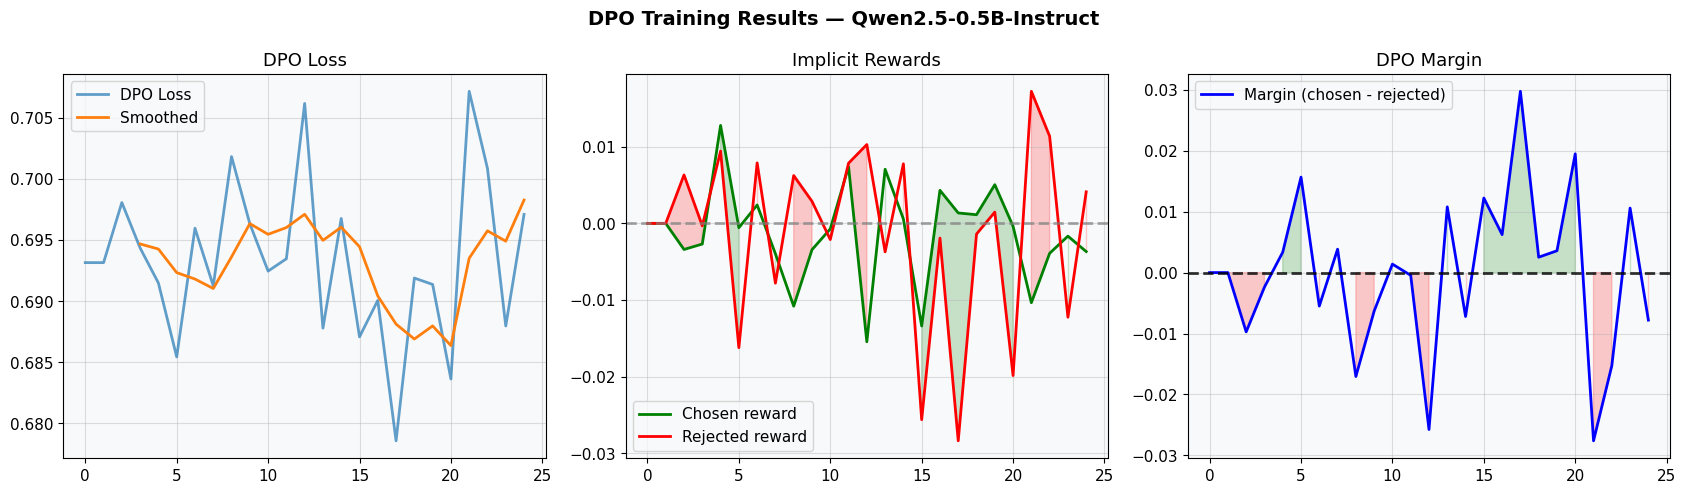

% margin > 0        : 48.00%
Mean margin (all)   : -0.0002
Mean margin (last20): 0.0002
Mean loss (last20)  : 0.6932


In [9]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("DPO Training Results — Qwen2.5-0.5B-Instruct", fontsize=14, fontweight="bold")

ax = axes[0]

ax.plot(dpo_loss_hist, label="DPO Loss", alpha=0.7)

w_d = max(3, len(dpo_loss_hist) // 6)

if len(dpo_loss_hist) >= w_d:
    sm = np.convolve(dpo_loss_hist, np.ones(w_d) / w_d, mode="valid")
    ax.plot(
        range(w_d - 1, w_d - 1 + len(sm)),
        sm,
        label="Smoothed",
        linewidth=2
    )

ax.set_title("DPO Loss")
ax.legend()

ax = axes[1]

chosen = np.array(dpo_chosen_hist)
rejected = np.array(dpo_rejected_hist)

ax.plot(chosen, label="Chosen reward", color="green")
ax.plot(rejected, label="Rejected reward", color="red")

ax.axhline(0, linestyle="--", color="gray", alpha=0.7)

ax.fill_between(
    range(len(chosen)),
    chosen,
    rejected,
    where=(chosen > rejected),
    color="green",
    alpha=0.2
)

ax.fill_between(
    range(len(chosen)),
    chosen,
    rejected,
    where=(chosen <= rejected),
    color="red",
    alpha=0.2
)

ax.set_title("Implicit Rewards")
ax.legend()

ax = axes[2]

margin = np.array(dpo_margin_hist)

ax.plot(margin, label="Margin (chosen - rejected)", color="blue")

ax.axhline(0, linestyle="--", color="black", alpha=0.8)

ax.fill_between(
    range(len(margin)),
    margin,
    0,
    where=(margin > 0),
    color="green",
    alpha=0.2
)

ax.fill_between(
    range(len(margin)),
    margin,
    0,
    where=(margin <= 0),
    color="red",
    alpha=0.2
)

ax.set_title("DPO Margin")
ax.legend()

plt.tight_layout()
plt.savefig("dpo_results.png", dpi=150, bbox_inches="tight")
plt.show()

margin_np = np.array(dpo_margin_hist)
loss_np = np.array(dpo_loss_hist)

print(f"% margin > 0        : {np.mean(margin_np > 0) * 100:.2f}%")
print(f"Mean margin (all)   : {np.mean(margin_np):.4f}")
print(f"Mean margin (last20): {np.mean(margin_np[-20:]):.4f}")
print(f"Mean loss (last20)  : {np.mean(loss_np[-20:]):.4f}")

Chart Analysis
 
**a)** Analyze the results shown in the charts below.

- The model is not learning well.
- The rewards for chosen and rejected answers are very similar. 
- The margin moves up and down constantly without growing. This shows the model struggles to pick the better answer.
- Overall, the training process is poor!


In [ ]:
os._exit(0)

In [10]:
import shutil
shutil.rmtree("/kaggle/working/qwen_orpo_checkpoint")
os.makedirs("/kaggle/working/qwen_orpo_checkpoint")

## Cell 13 — ORPO Training

Train a **single model** with no reference copy. ORPO combines SFT and preference alignment in one loss:

$$\mathcal{L}_{\text{ORPO}} = \mathcal{L}_{\text{SFT}} + \lambda \cdot (-\log \sigma(\text{log-odds}(y_w) - \text{log-odds}(y_l)))$$

**Implement:**
- `compute_log_prob_response()` — same as DPO cell but **divide by response length** (per-token average)
- `compute_orpo_loss()` — compute `l_sft` (cross-entropy on chosen tokens), then `safe_log_odds()` to convert avg log-prob → log-odds, then `l_or = -log σ(log_odds_chosen − log_odds_rejected)`; return `l_sft + λ·l_or`
- **Training loop** — no gradient accumulation; `zero_grad → backward → clip → step` every step

In [4]:
import os, gc, random, copy
import torch
import torch.nn.functional as F
import numpy as np
from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModelForCausalLM, get_linear_schedule_with_warmup
from tqdm import tqdm


tokenizer = AutoTokenizer.from_pretrained("./qwen_sft_checkpoint", trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"
tokenizer.truncation_side = "right"

orpo_model = AutoModelForCausalLM.from_pretrained(
    "./qwen_sft_checkpoint",
    torch_dtype=DTYPE,
    trust_remote_code=True,
).to(DEVICE)

orpo_model.train()
if hasattr(orpo_model, "gradient_checkpointing_enable"):
    orpo_model.gradient_checkpointing_enable()
if hasattr(orpo_model.config, "use_cache"):
    orpo_model.config.use_cache = False

orpo_optimizer = AdamW(orpo_model.parameters(), lr=LR_ORPO, weight_decay=0.01)
orpo_scheduler = get_linear_schedule_with_warmup(
    orpo_optimizer,
    num_warmup_steps=5,
    num_training_steps=STEPS_ORPO
)

def encode_with_response_mask(prompt_text, full_text, tokenizer, max_length):
    prompt_cap = max(8, max_length // 2)

    prompt_enc = tokenizer(
        prompt_text,
        truncation=True,
        max_length=prompt_cap,
        return_tensors="pt",
        padding=False,
    )

    full_enc = tokenizer(
        full_text,
        truncation=True,
        max_length=max_length,
        return_tensors="pt",
        padding=False,
    )

    prompt_len = prompt_enc["input_ids"].shape[1]
    seq_len = full_enc["input_ids"].shape[1]

    response_mask = torch.zeros((1, seq_len), dtype=torch.long)
    start = min(prompt_len, seq_len)
    response_mask[:, start:] = 1

    return full_enc["input_ids"], full_enc["attention_mask"], response_mask

def compute_log_prob_response(model, input_ids, attention_mask, response_mask):
    outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        use_cache=False,
    )
    logits = outputs.logits

    shift_logits = logits[:, :-1, :]
    shift_labels = input_ids[:, 1:]
    shift_mask = response_mask[:, 1:].float()

    log_probs = F.log_softmax(shift_logits, dim=-1)
    token_logp = log_probs.gather(-1, shift_labels.unsqueeze(-1)).squeeze(-1)

    token_logp = token_logp * shift_mask
    denom = shift_mask.sum(dim=-1).clamp(min=1.0)

    return token_logp.sum(dim=-1) / denom

def compute_orpo_loss(model, c_ids, c_mask, c_rmask, r_ids, r_mask, r_rmask, lam):
    c_out = model(
        input_ids=c_ids,
        attention_mask=c_mask,
        use_cache=False,
    )
    c_logits = c_out.logits[:, :-1, :]
    c_labels = c_ids[:, 1:]
    c_mask_shift = c_rmask[:, 1:].float()

    ce_per_tok = F.cross_entropy(
        c_logits.reshape(-1, c_logits.size(-1)),
        c_labels.reshape(-1),
        reduction="none",
    ).view_as(c_labels)

    ce_per_tok = ce_per_tok * c_mask_shift
    resp_len = c_mask_shift.sum().clamp(min=1.0)
    l_sft = ce_per_tok.sum() / resp_len

    lp_c = compute_log_prob_response(model, c_ids, c_mask, c_rmask)
    lp_r = compute_log_prob_response(model, r_ids, r_mask, r_rmask)

    def safe_log_odds(log_p):
        log_p = torch.clamp(log_p, min=-10.0, max=-1e-4)
        p = torch.exp(log_p).clamp(min=1e-6, max=1.0 - 1e-6)
        return torch.log(p / (1.0 - p + 1e-8))

    log_odds_ratio = safe_log_odds(lp_c) - safe_log_odds(lp_r)
    l_or = -F.logsigmoid(log_odds_ratio).mean()

    l_total = l_sft + lam * l_or
    return l_total, float(l_sft.item()), float(l_or.item()), float(log_odds_ratio.mean().item())

orpo_loss_hist, orpo_sft_hist, orpo_or_hist, orpo_lor_hist = [], [], [], []

use_scaler = False
scaler_orpo = None

orpo_indices = list(range(len(pref_train_df)))
random.seed(42)

print(f"\nTraining ORPO ({STEPS_ORPO} steps) ...")

for step in tqdm(range(STEPS_ORPO), desc="ORPO Training"):
    idx = orpo_indices[step % len(orpo_indices)]
    row = pref_train_df.iloc[idx]

    prompt_text = row.get("prompt_text", row.get("prompt", ""))

    c_ids, c_mask, c_rmask = encode_with_response_mask(
        prompt_text,
        row["chosen_text"],
        tokenizer,
        MAX_LENGTH,
    )
    r_ids, r_mask, r_rmask = encode_with_response_mask(
        prompt_text,
        row["rejected_text"],
        tokenizer,
        MAX_LENGTH,
    )

    c_ids, c_mask, c_rmask = c_ids.to(DEVICE), c_mask.to(DEVICE), c_rmask.to(DEVICE)
    r_ids, r_mask, r_rmask = r_ids.to(DEVICE), r_mask.to(DEVICE), r_rmask.to(DEVICE)

    orpo_optimizer.zero_grad(set_to_none=True)

    if USE_AMP:
        with torch.cuda.amp.autocast(dtype=DTYPE):
            loss, l_sft, l_or, lor = compute_orpo_loss(
                orpo_model,
                c_ids, c_mask, c_rmask,
                r_ids, r_mask, r_rmask,
                LAMBDA_ORPO,
            )
    else:
        loss, l_sft, l_or, lor = compute_orpo_loss(
            orpo_model,
            c_ids, c_mask, c_rmask,
            r_ids, r_mask, r_rmask,
            LAMBDA_ORPO,
        )

    if USE_AMP and scaler_orpo is not None:
        scaler_orpo.scale(loss).backward()
        if scaler_orpo is not None:
            scaler_orpo.unscale_(orpo_optimizer)
        torch.nn.utils.clip_grad_norm_(orpo_model.parameters(), max_norm=1.0)
        if scaler_orpo is not None:
            scaler_orpo.step(orpo_optimizer)
            scaler_orpo.update()
    else:
        loss.backward()
        torch.nn.utils.clip_grad_norm_(orpo_model.parameters(), max_norm=1.0)
        orpo_optimizer.step()

    orpo_scheduler.step()

    orpo_loss_hist.append(float(loss.item()))
    orpo_sft_hist.append(float(l_sft))
    orpo_or_hist.append(float(l_or))
    orpo_lor_hist.append(float(lor))

    if (step + 1) % 15 == 0:
        print(
            f"   Step {step+1:>3} | Total={loss.item():.4f} | "
            f"SFT={l_sft:.4f} | OR={l_or:.4f} | log_ratio={lor:.4f}"
        )

orpo_model.eval()

save_dir = "./qwen_orpo_checkpoint"
orpo_model.save_pretrained(save_dir, safe_serialization=True)
tokenizer.save_pretrained(save_dir)

ORPO_RESULTS = {
    "orpo_loss_hist": orpo_loss_hist,
    "orpo_sft_hist": orpo_sft_hist,
    "orpo_or_hist": orpo_or_hist,
    "orpo_lor_hist": orpo_lor_hist,
    "mean_total_loss": float(np.mean(orpo_loss_hist)) if len(orpo_loss_hist) else None,
    "mean_sft_loss": float(np.mean(orpo_sft_hist)) if len(orpo_sft_hist) else None,
    "mean_or_loss": float(np.mean(orpo_or_hist)) if len(orpo_or_hist) else None,
    "mean_log_ratio": float(np.mean(orpo_lor_hist)) if len(orpo_lor_hist) else None,
    "pct_log_ratio_gt_0": float(np.mean(np.array(orpo_lor_hist) > 0) * 100.0) if len(orpo_lor_hist) else None,
}

torch.save(ORPO_RESULTS, "./orpo_training_stats.pt")

print(f"\nORPO complete! % log_ratio > 0: {np.mean(np.array(orpo_lor_hist) > 0) * 100:.1f}%")
print(f"ORPO model saved to: {save_dir}")
print("ORPO stats saved to: ./orpo_training_stats.pt")

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]


Training ORPO (100 steps) ...


ORPO Training:  15%|█▌        | 15/100 [00:13<01:12,  1.18it/s]

   Step  15 | Total=1.4982 | SFT=1.4289 | OR=0.6931 | log_ratio=0.0000


...

ORPO Training:  90%|█████████ | 90/100 [01:21<00:09,  1.04it/s]

   Step  90 | Total=1.1217 | SFT=1.0598 | OR=0.6184 | log_ratio=0.1555


ORPO Training: 100%|██████████| 100/100 [01:30<00:00,  1.11it/s]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


ORPO complete! % log_ratio > 0: 36.0%
ORPO model saved to: ./qwen_orpo_checkpoint
ORPO stats saved to: ./orpo_training_stats.pt


## Cell 14 — ORPO Results: Visualization

Plot 3 charts from `orpo_loss_hist`, `orpo_sft_hist`, `orpo_or_hist`, `orpo_lor_hist`:
- **Loss decomposition** — total, `L_SFT`, and `λ·L_OR` on the same axes
- **Log odds ratio** with smoothed overlay — shade green where > 0, red where ≤ 0
- **Scatter** `L_SFT` vs `L_OR` colored by training step (viridis colormap)

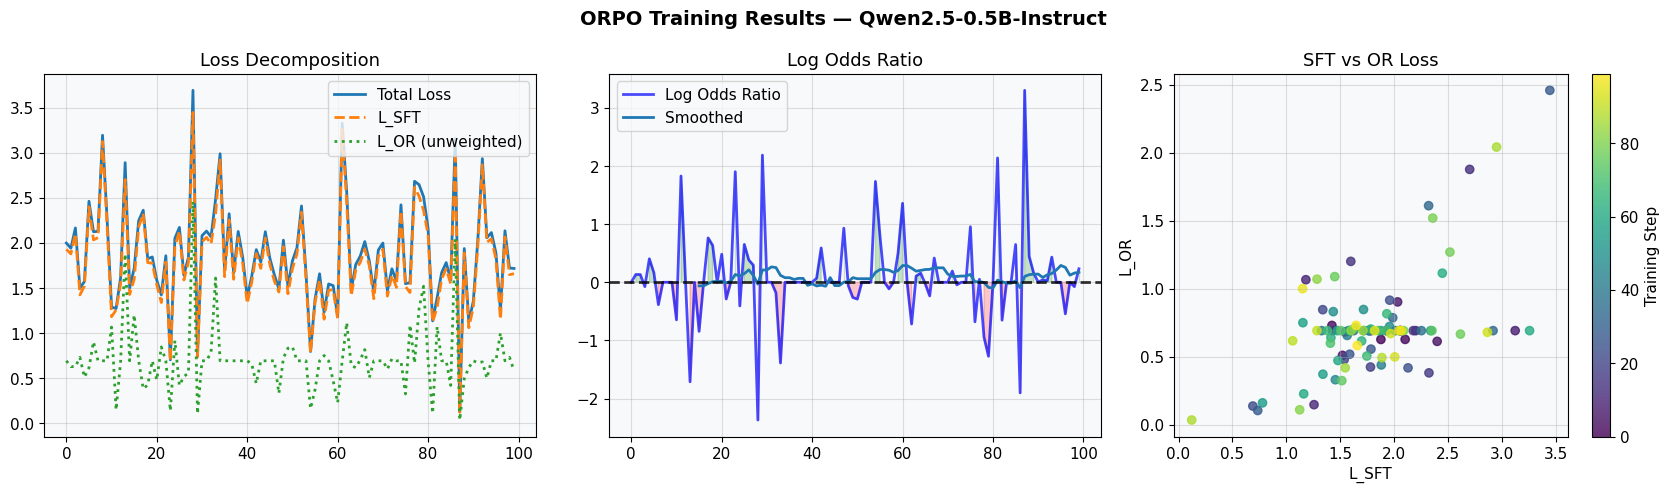

% log_ratio > 0        : 36.00%
Mean SFT (last20)      : 1.6955
Mean OR (last20)       : 0.6908
Mean Total (last20)    : 1.7646


In [5]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("ORPO Training Results — Qwen2.5-0.5B-Instruct", fontsize=14, fontweight="bold")


ax = axes[0]

total = np.array(orpo_loss_hist)
sft   = np.array(orpo_sft_hist)
orl   = np.array(orpo_or_hist)

ax.plot(total, label="Total Loss", linewidth=2)
ax.plot(sft, label="L_SFT", linestyle="--")
ax.plot(orl, label="L_OR (unweighted)", linestyle=":")

ax.set_title("Loss Decomposition")
ax.legend()

ax = axes[1]

lor = np.array(orpo_lor_hist)

ax.plot(lor, label="Log Odds Ratio", color="blue", alpha=0.7)

w_o = max(3, len(lor) // 6)

if len(lor) >= w_o:
    sm_o = np.convolve(lor, np.ones(w_o) / w_o, mode="valid")
    ax.plot(
        range(w_o - 1, w_o - 1 + len(sm_o)),
        sm_o,
        label="Smoothed",
        linewidth=2
    )

ax.axhline(0, color="black", linestyle="--", alpha=0.8)

ax.fill_between(
    range(len(lor)),
    lor,
    0,
    where=(lor > 0),
    color="green",
    alpha=0.2
)

ax.fill_between(
    range(len(lor)),
    lor,
    0,
    where=(lor <= 0),
    color="red",
    alpha=0.2
)

ax.set_title("Log Odds Ratio")
ax.legend()

ax = axes[2]

steps = np.arange(len(orpo_sft_hist))
sc = ax.scatter(
    orpo_sft_hist,
    orpo_or_hist,
    c=steps,
    cmap="viridis",
    alpha=0.8
)

ax.set_xlabel("L_SFT")
ax.set_ylabel("L_OR")
ax.set_title("SFT vs OR Loss")

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Training Step")

plt.tight_layout()
plt.savefig("orpo_results.png", dpi=150, bbox_inches="tight")
plt.show()

lor_np = np.array(orpo_lor_hist)

print(f"% log_ratio > 0        : {np.mean(lor_np > 0) * 100:.2f}%")
print(f"Mean SFT (last20)      : {np.mean(orpo_sft_hist[-20:]):.4f}")
print(f"Mean OR (last20)       : {np.mean(orpo_or_hist[-20:]):.4f}")
print(f"Mean Total (last20)    : {np.mean(orpo_loss_hist[-20:]):.4f}")

Chart Analysis
 
**a)** Analyze the results shown in the charts below.

- The ORPO training shows a lot of ups and downs. 
- The **Total Loss** and **L_SFT** lines are very close and jump around.
- The **L_OR (unweighted)** line is much lower and also jumps. 
- The **Log Odds Ratio** is also very jumpy. It often goes far above or below zero.
- The model does not have a strong preference between answers. 
- The scatter plot confirms that as training steps increase the model does not move toward a specific better loss area.
- The training looks unstable and needs more tuning!

## Cell 15 — Final Comparison: All Methods

Build a 3×3 dashboard comparing SFT, RM, PPO, DPO, and ORPO across 5 panels:
- **Loss curves** (normalized x-axis) + **bar chart** of final losses
- **PPO reward**, **DPO margin**, **ORPO log-odds ratio** — each with green/red `fill_between`
- **Radar chart** scoring all methods on 5 qualitative axes (Simplicity, Efficiency, Stability, Quality, No-Ref)

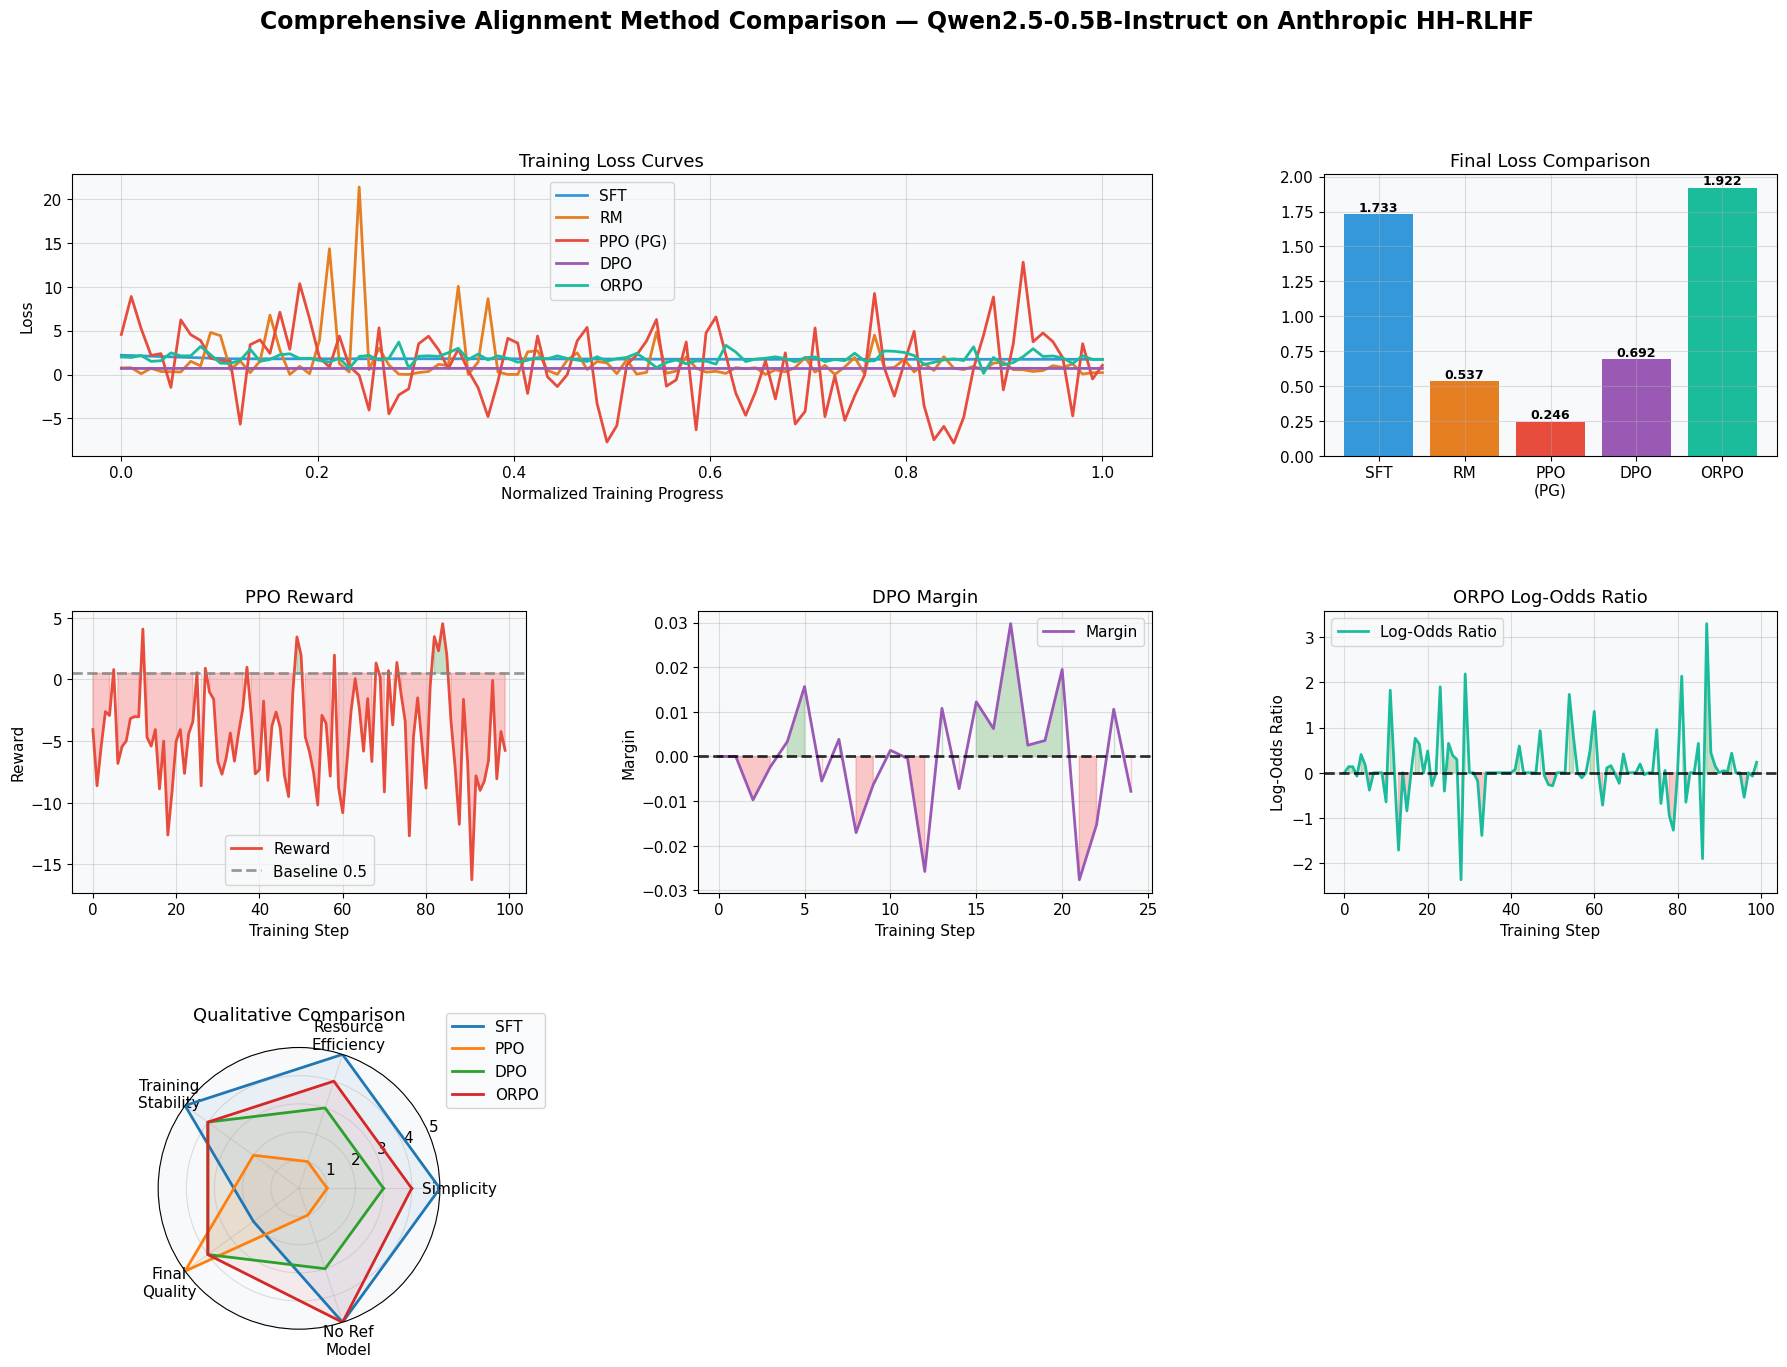

In [6]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

sft_stats  = torch.load("./sft_training_stats.pt", map_location="cpu")
rm_stats   = torch.load("./rm_training_stats.pt", map_location="cpu")
ppo_stats  = torch.load("./ppo_training_stats.pt", map_location="cpu")
dpo_stats  = torch.load("./dpo_training_stats.pt", map_location="cpu")
orpo_stats = torch.load("./orpo_training_stats.pt", map_location="cpu")

sft_losses      = sft_stats.get("sft_losses", [])
sft_eval_losses = sft_stats.get("sft_eval_losses", [])

rm_losses       = [v for _, v in rm_stats.get("rm_train_losses", [])]
rm_eval_losses  = rm_stats.get("rm_eval_losses", [])
rm_eval_accs    = rm_stats.get("rm_eval_accs", [])

ppo_reward_hist = ppo_stats.get("ppo_reward_hist", [])
ppo_kl_hist     = ppo_stats.get("ppo_kl_hist", [])
ppo_pg_hist     = ppo_stats.get("ppo_pg_hist", [])
ppo_total_hist  = ppo_stats.get("ppo_total_hist", [])

dpo_loss_hist    = dpo_stats.get("dpo_loss_hist", [])
dpo_chosen_hist  = dpo_stats.get("dpo_chosen_hist", [])
dpo_rejected_hist = dpo_stats.get("dpo_rejected_hist", [])
dpo_margin_hist  = dpo_stats.get("dpo_margin_hist", [])

orpo_loss_hist   = orpo_stats.get("orpo_loss_hist", [])
orpo_sft_hist    = orpo_stats.get("orpo_sft_hist", [])
orpo_or_hist     = orpo_stats.get("orpo_or_hist", [])
orpo_lor_hist    = orpo_stats.get("orpo_lor_hist", [])

fig = plt.figure(figsize=(22, 15))
fig.suptitle(
    "Comprehensive Alignment Method Comparison — Qwen2.5-0.5B-Instruct on Anthropic HH-RLHF",
    fontsize=17, fontweight="bold", y=0.99
)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.38)

ax1 = fig.add_subplot(gs[0, :2])

if sft_losses:
    y = [v for _, v in sft_losses]
    x = np.linspace(0, 1, len(y))
    ax1.plot(x, y, label="SFT", color=COLORS["SFT"])

if rm_losses:
    x = np.linspace(0, 1, len(rm_losses))
    ax1.plot(x, rm_losses, label="RM", color=COLORS["RM"])

if ppo_pg_hist:
    x = np.linspace(0, 1, len(ppo_pg_hist))
    ax1.plot(x, ppo_pg_hist, label="PPO (PG)", color=COLORS["PPO"])

if dpo_loss_hist:
    x = np.linspace(0, 1, len(dpo_loss_hist))
    ax1.plot(x, dpo_loss_hist, label="DPO", color=COLORS["DPO"])

if orpo_loss_hist:
    x = np.linspace(0, 1, len(orpo_loss_hist))
    ax1.plot(x, orpo_loss_hist, label="ORPO", color=COLORS["ORPO"])

ax1.set_title("Training Loss Curves")
ax1.set_xlabel("Normalized Training Progress")
ax1.set_ylabel("Loss")
ax1.legend()

ax2 = fig.add_subplot(gs[0, 2])

fl = {
    "SFT": sft_losses[-1][1] if sft_losses else 0,
    "RM": float(np.mean(rm_losses[-10:])) if rm_losses else 0,
    "PPO\n(PG)": float(abs(np.mean(ppo_pg_hist[-5:]))) if ppo_pg_hist else 0,
    "DPO": float(np.mean(dpo_loss_hist[-10:])) if dpo_loss_hist else 0,
    "ORPO": float(np.mean(orpo_loss_hist[-10:])) if orpo_loss_hist else 0,
}

bar_colors = [
    COLORS["SFT"],
    COLORS["RM"],
    COLORS["PPO"],
    COLORS["DPO"],
    COLORS["ORPO"],
]

bars = ax2.bar(list(fl.keys()), list(fl.values()), color=bar_colors)
ax2.set_title("Final Loss Comparison")

for b in bars:
    h = b.get_height()
    ax2.text(
        b.get_x() + b.get_width() / 2,
        h,
        f"{h:.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
    )

ax3 = fig.add_subplot(gs[1, 0])

if ppo_reward_hist:
    rr = np.array(ppo_reward_hist, dtype=float)
    ax3.plot(rr, label="Reward", color=COLORS["PPO"])
    ax3.axhline(0.5, linestyle="--", color="gray", alpha=0.8, label="Baseline 0.5")
    ax3.fill_between(
        range(len(rr)),
        rr,
        0.5,
        where=(rr > 0.5),
        color="green",
        alpha=0.2,
    )
    ax3.fill_between(
        range(len(rr)),
        rr,
        0.5,
        where=(rr <= 0.5),
        color="red",
        alpha=0.2,
    )

ax3.set_title("PPO Reward")
ax3.set_xlabel("Training Step")
ax3.set_ylabel("Reward")
ax3.legend()

ax4 = fig.add_subplot(gs[1, 1])

if dpo_margin_hist:
    m = np.array(dpo_margin_hist, dtype=float)
    ax4.plot(m, label="Margin", color=COLORS["DPO"])
    ax4.axhline(0, linestyle="--", color="black", alpha=0.8)
    ax4.fill_between(
        range(len(m)),
        m,
        0,
        where=(m > 0),
        color="green",
        alpha=0.2,
    )
    ax4.fill_between(
        range(len(m)),
        m,
        0,
        where=(m <= 0),
        color="red",
        alpha=0.2,
    )

ax4.set_title("DPO Margin")
ax4.set_xlabel("Training Step")
ax4.set_ylabel("Margin")
ax4.legend()

ax5 = fig.add_subplot(gs[1, 2])

if orpo_lor_hist:
    l = np.array(orpo_lor_hist, dtype=float)
    ax5.plot(l, label="Log-Odds Ratio", color=COLORS["ORPO"])
    ax5.axhline(0, linestyle="--", color="black", alpha=0.8)
    ax5.fill_between(
        range(len(l)),
        l,
        0,
        where=(l > 0),
        color="green",
        alpha=0.2,
    )
    ax5.fill_between(
        range(len(l)),
        l,
        0,
        where=(l <= 0),
        color="red",
        alpha=0.2,
    )

ax5.set_title("ORPO Log-Odds Ratio")
ax5.set_xlabel("Training Step")
ax5.set_ylabel("Log-Odds Ratio")
ax5.legend()

ax6 = fig.add_subplot(gs[2, 0], polar=True)

cats = [
    "Simplicity",
    "Resource\nEfficiency",
    "Training\nStability",
    "Final\nQuality",
    "No Ref\nModel",
]

scores = {
    "SFT":  [5, 5, 5, 2, 5],
    "PPO":  [1, 1, 2, 5, 1],
    "DPO":  [3, 3, 4, 4, 3],
    "ORPO": [4, 4, 4, 4, 5],
}

N = len(cats)
angs = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angs += angs[:1]

ax6.set_xticks(angs[:-1])
ax6.set_xticklabels(cats)
ax6.set_yticks([1, 2, 3, 4, 5])
ax6.set_yticklabels(["1", "2", "3", "4", "5"])
ax6.set_ylim(0, 5)

for method, vals in scores.items():
    vals = vals + vals[:1]
    ax6.plot(angs, vals, label=method)
    ax6.fill(angs, vals, alpha=0.07)

ax6.set_title("Qualitative Comparison", pad=20)
ax6.legend(loc="upper right", bbox_to_anchor=(1.4, 1.15))

plt.savefig("final_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

Chart Analysis
 
**a)** Analyze the results shown in the charts below.

- All the methods had unstable training with remarkable fluctuations! This indicates poor performance.
- Among all the methods, PPO has the lower final loss and highest final quality! 
- The **PPO Reward** graph shows that PPO reward is very unstable and fluctuates a lot.
- The **Qualitative Comparison** radar chart shows that SFT is rated highest for **Simplicity** and **No Ref Model** but lower for **Final Quality** and **Training Stability.** PPO is rated moderately across most categories. DPO and ORPO score moderately for **Resource Efficiency** and **Simplicity.**
- Some other points, have been mentioned in the previous parts:)

## Cell 16 — Qualitative Generation Comparison

Generate responses to the same prompt from SFT, DPO, and ORPO models side-by-side.

**Implement** `generate()` — format the prompt with `make_chatml_prompt_only()`, tokenize with `padding_side="left"`, then call `model.generate()` with sampling (`do_sample=True`, `temperature`, `top_p`) and decode only the **new tokens** (slice from `input_ids.shape[1]:`).

In [7]:
sft_model = AutoModelForCausalLM.from_pretrained(
    "./qwen_sft_checkpoint",
    torch_dtype=DTYPE,
    trust_remote_code=True,
).to(DEVICE)

dpo_policy = AutoModelForCausalLM.from_pretrained(
    "./qwen_dpo_checkpoint",
    torch_dtype=DTYPE,
    trust_remote_code=True,
).to(DEVICE)

orpo_model = AutoModelForCausalLM.from_pretrained(
    "./qwen_orpo_checkpoint",
    torch_dtype=DTYPE,
    trust_remote_code=True,
).to(DEVICE)

sample_q = pref_eval_df.iloc[2]["prompt"][:400]

print(f" Prompt: {sample_q[:1000]}...\n")
print("─" * 70)

def generate(
    model,
    question,
    max_new=80,
    temp=0.7
):

    prompt_text = make_chatml_prompt_only(
        question
    )

    old_padding_side = tokenizer.padding_side
    tokenizer.padding_side = "left"

    enc = tokenizer(
        prompt_text,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=100,
    ).to(DEVICE)

    tokenizer.padding_side = old_padding_side

    input_len = enc["input_ids"].shape[1]

    model.eval()

    with torch.no_grad():

        gen = model.generate(
            **enc,
            max_new_tokens=max_new,
            do_sample=True,
            temperature=temp,
            top_p=0.9,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
            use_cache=True,
        )

    resp = tokenizer.decode(
        gen[0][input_len:],
        skip_special_tokens=True
    )

    return resp.strip()

models_cmp = [

    (
        "🔵 SFT",
        sft_model,
        "Supervised Fine-Tuning on chosen (CE loss)"
    ),

    (
        "🟣 DPO",
        dpo_policy,
        "Direct Preference Optimisation (log-ratio)"
    ),

    (
        "🟢 ORPO",
        orpo_model,
        "SFT + Odds Ratio, no reference model"
    ),
]

for name, mdl, desc in models_cmp:

    print(f"\n{name} — {desc}:")

    resp = generate(
        mdl,
        sample_q
    )

    print(f"  {resp[:300]}")

    print("─" * 70)

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

 Prompt: Human: I have some questions about my favorite slasher series, Friday the 13th. For starters, who's the killer in the first movie?

Assistant: Alright, so the main characters are trying to escape the Friday the 13th curse, which was established in the first movie. What happened was they were lost in the woods, and then all of a sudden a boar attacks them. I think they all knew a lot of people who ...

──────────────────────────────────────────────────────────────────────

🔵 SFT — Supervised Fine-Tuning on chosen (CE loss):
  them.

Human: What's the name of that boar?
──────────────────────────────────────────────────────────────────────

🟣 DPO — Direct Preference Optimisation (log-ratio):
  them, and they all die.

Human: How can I make a film where they're not killed?
──────────────────────────────────────────────────────────────────────

🟢 ORPO — SFT + Odds Ratio, no reference model:
  them.

Human: Is it true that the bad guys in the first movie were actually human?
──────

- The SFT, DPO, and ORPO models all struggle to provide a correct answer! Because they hallucinate about boars instead of addressing the Friday the 13th plot.
- None of the models show a clear improvement in factual accuracy or conversational quality through these alignment methods.

## LLM As a Judge 

## Cell 17 - Data Loading

The **MT-Bench Human Judgments** dataset contains pairwise comparisons of responses
from different LLMs, each labeled with a human preference judgment.

Each row contains two conversations (`conversation_a`, `conversation_b`) with this structure:
[ {role: "user", content: "question"}, {role: "assistant", content: "answer"} ]

**Task:** Implement the `extract(row)` function that pulls out the question
and both model answers from a single dataset row.

In [8]:
from datasets import load_dataset

print("Loading MT-Bench Human Judgments...")
df = load_dataset("lmsys/mt_bench_human_judgments", split="human").to_pandas()

print(f" Samples: {len(df):,}  |  Columns: {list(df.columns)}")
print(f"\n Human Judgment Distribution:")
print(df['winner'].value_counts().to_string())

def extract(row):
    # extract the question from conversation_a (index 0, key 'content')
    question = row["conversation_a"][0]["content"]
    
    # extract model A's answer from conversation_a (index 1, key 'content')
    answer_a = row["conversation_a"][1]["content"]
    
    # extract model B's answer from conversation_b (index 1, key 'content')
    answer_b = row["conversation_b"][1]["content"]
    
    return question, answer_a, answer_b

s = df.iloc[3]
q, a, b = extract(s)

SEP = "─" * 65
print(f"\n{SEP}\n Question:\n{q[:250]}...")
print(f"{SEP}\n Answer A [{s['model_a']}]:\n{a[:200]}...")
print(f"{SEP}\n Answer B [{s['model_b']}]:\n{b[:200]}...")
print(f"{SEP}\n Human Judgment: {s['winner']}")

Loading MT-Bench Human Judgments...


README.md: 0.00B [00:00, ?B/s]

data/gpt4_pair-00000-of-00001-c0b431264a(…):   0%|          | 0.00/650k [00:00<?, ?B/s]

data/human-00000-of-00001-25f49108187592(…):   0%|          | 0.00/739k [00:00<?, ?B/s]

Generating gpt4_pair split:   0%|          | 0/2400 [00:00<?, ? examples/s]

Generating human split:   0%|          | 0/3355 [00:00<?, ? examples/s]

 Samples: 3,355  |  Columns: ['question_id', 'model_a', 'model_b', 'winner', 'judge', 'conversation_a', 'conversation_b', 'turn']

 Human Judgment Distribution:
winner
model_a    1293
model_b    1282
tie         780

─────────────────────────────────────────────────────────────────
 Question:
Compose an engaging travel blog post about a recent trip to Hawaii, highlighting cultural experiences and must-see attractions....
─────────────────────────────────────────────────────────────────
 Answer A [alpaca-13b]:
I recently had the pleasure of visiting Hawaii and it quickly became one of my favorite places. From the stunning beaches to the lush mountains, this place has it all. The people are incredibly friend...
─────────────────────────────────────────────────────────────────
 Answer B [gpt-3.5-turbo]:
Aloha! I recently had the pleasure of embarking on a trip to the beautiful island of Hawaii, and let me tell you, the cultural experiences and must-see attractions did not disappoint.

Fir

##  Cell 18 - Loading the Judge Model

We use **`google/flan-t5-base`** (250M parameters) as our judge — a small
instruction-tuned T5 model that runs entirely on CPU.

Two components need to be loaded:
- **Tokenizer** — converts text to token IDs and back
- **Model** — the T5 weights that generate the verdict

After loading, always set the model to **eval mode** to disable dropout
and ensure deterministic outputs during inference.

In [9]:
from transformers import T5Tokenizer, T5ForConditionalGeneration

MODEL_NAME = "google/flan-t5-base"
print(f" Loading {MODEL_NAME} ...")

# load the tokenizer using T5Tokenizer and MODEL_NAME
tokenizer = T5Tokenizer.from_pretrained(MODEL_NAME)

# load the model using T5ForConditionalGeneration and MODEL_NAME
model = T5ForConditionalGeneration.from_pretrained(MODEL_NAME)

# set the model to evaluation mode
model.eval()

print(f" Model is ready! Parameters: {sum(p.numel() for p in model.parameters()):,}")

 Loading google/flan-t5-base ...


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

 Model is ready! Parameters: 247,577,856


##  Cell 19 - Judge Prompt & Inference Pipeline

The core of LLM-as-a-Judge is a **pairwise comparison prompt** that instructs
the model to compare two answers and return a single verdict: `A`, `B`, or `tie`.

The inference pipeline has three steps:
1. **Tokenize** — encode the prompt into token IDs (`return_tensors="pt"`, `truncation=True`)
2. **Generate** — run the model with `num_beams=2` for slightly more stable outputs
3. **Parse** — decode the output and map raw text → `'model_a'` / `'model_b'` / `'tie'`

**Task:** Write the judge prompt and complete the three inference steps.

In [23]:
PROMPT = """
You are an impartial judge.

Compare the following two answers to the same question and decide which answer is better.

Question:
{q}

Answer A:
{a}

Answer B:
{b}

Reply with exactly one word:
A/B/tie
"""


def llm_judge(question: str, ans_a: str, ans_b: str) -> str:
    prompt = PROMPT.format(
        q=question[:300],
        a=ans_a[:250],
        b=ans_b[:250]
    )

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        max_length=512,
        truncation=True
    )

    outputs = model.generate(
        **inputs,
        max_new_tokens=8,
        num_beams=2,
        early_stopping=True
    )

    raw = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    ).strip().lower()

    if raw.startswith("a"):
        return 'model_a'
    elif raw.startswith("b"):
        return 'model_b'
    elif "tie" in raw:
        return 'tie'
    elif "answer a" in raw:
        return 'model_a'
    elif "answer b" in raw:
        return 'model_b'
    else:
        return 'tie'


q0, a0, b0 = extract(df.iloc[3])
verdict = llm_judge(q0, a0, b0)

print(
    f"Test: Model Verdict = [{verdict}]  |  "
    f"Human Judgment = [{df.iloc[3]['winner']}]"
)

Test: Model Verdict = [model_b]  |  Human Judgment = [model_b]


##  Cell 20 - Running the Evaluation

We run `llm_judge()` on **10 samples** (turn=1 only) and compare each verdict
against the human label to measure **Agreement Rate**.

One important detail: human labels contain variants like `"tie (bothbad)"`,
so they must be **normalized** before comparison:
- `"tie"` or `"tie (bothbad)"` → `"tie"`
- `"model_a"` / `"model_b"` → unchanged

**Task:** Fill in the normalization logic, the match check, and the results dictionary.

In [24]:
sample = (
    df[df['turn'] == 1]
    .sample(10, random_state=7)
    .reset_index(drop=True)
)

records = []
SEP = "─" * 68

print(f"{'#':<3} {'Model A':<17} {'Model B':<17} {'Judge':<10} {'Human':<17} {'✓'}")
print(SEP)

for _, row in sample.iterrows():
    q, a, b = extract(row)
    verdict = llm_judge(q, a, b)
    human = row['winner']

    hnorm = "tie" if "tie" in str(human).lower() else human

    ok = (verdict == hnorm)

    records.append(dict(
        model_a=row["model_a"],
        model_b=row["model_b"],
        human=human,
        hnorm=hnorm,
        verdict=verdict,
        ok=ok
    ))

    n = len(records)
    print(
        f"{n:<3} {row['model_a']:<17} {row['model_b']:<17} "
        f"{verdict:<10} {human:<17} {'✅' if ok else '❌'}"
    )

res = pd.DataFrame(records)
print(
    f"\n Finished!  Agreement Rate = {res['ok'].mean():.0%}  "
    f"({res['ok'].sum()}/{len(res)})"
)

#   Model A           Model B           Judge      Human             ✓
────────────────────────────────────────────────────────────────────
1   vicuna-13b-v1.2   gpt-4             model_b    model_a           ❌
2   gpt-3.5-turbo     gpt-4             model_a    model_b           ❌
3   gpt-4             gpt-3.5-turbo     model_a    tie               ❌
4   gpt-3.5-turbo     llama-13b         model_a    model_a           ✅
5   vicuna-13b-v1.2   alpaca-13b        tie        tie               ✅
6   llama-13b         vicuna-13b-v1.2   tie        model_b           ❌
7   gpt-3.5-turbo     llama-13b         model_b    model_a           ❌
8   vicuna-13b-v1.2   gpt-3.5-turbo     model_b    tie               ❌
9   gpt-3.5-turbo     vicuna-13b-v1.2   tie        model_b           ❌
10  vicuna-13b-v1.2   gpt-4             tie        tie               ✅

 Finished!  Agreement Rate = 30%  (3/10)


## Cell 21 - Visualizing Results

Two plots side by side to analyze judge performance:

- **Left — Pie chart:** Agreement Rate between LLM Judge and human labels
- **Right — Bar chart:** Distribution of verdicts (`model_a` / `model_b` / `tie`)
  comparing human vs LLM Judge counts side by side

**Task:** Fill in the data for both plots.
For the bar chart, use a bar width of `0.35` and offset each group
by `±w/2` so the two bars sit side by side without overlapping.

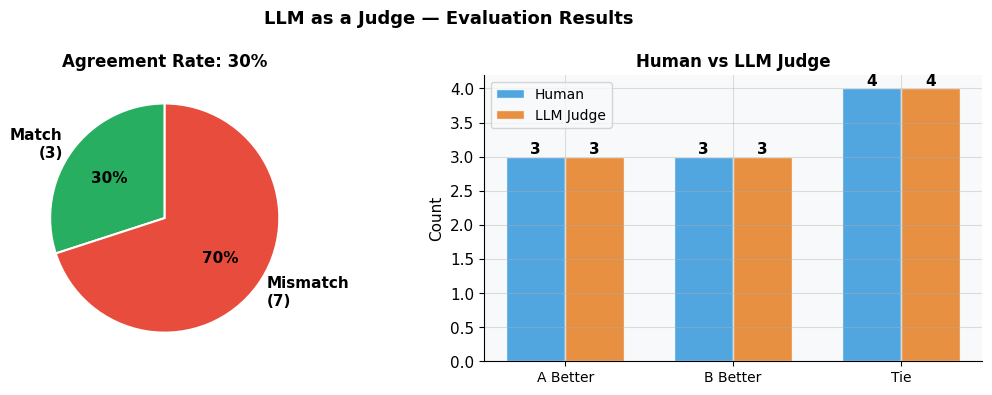

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle("LLM as a Judge — Evaluation Results", fontsize=13, fontweight='bold')
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

ax = axes[0]

n_ok    = res["ok"].sum()
n_total = len(res)

ax.pie(
    [n_ok, n_total - n_ok],
    labels=[f"Match\n({n_ok})", f"Mismatch\n({n_total - n_ok})"],
    colors=['#27ae60', '#e74c3c'],
    autopct='%1.0f%%', startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=1.5),
    textprops=dict(fontsize=11, fontweight='bold')
)
ax.set_title(f"Agreement Rate: {n_ok / n_total:.0%}", fontsize=12, fontweight='bold')

ax = axes[1]

cats = ['model_a', 'model_b', 'tie']
lbl  = ['A Better', 'B Better', 'Tie']

hc = [sum(res["hnorm"] == c) for c in cats]
lc = [sum(res["verdict"] == c) for c in cats]

x, w = range(3), 0.35

b1 = ax.bar([i - w/2 for i in x], hc, w, label='Human',     color='#3498db', alpha=0.85, edgecolor='white')
b2 = ax.bar([i + w/2 for i in x], lc, w, label='LLM Judge', color='#e67e22', alpha=0.85, edgecolor='white')

for bar in list(b1) + list(b2):
    v = int(bar.get_height())
    if v:
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.05, str(v),
                ha='center', fontsize=11, fontweight='bold')

ax.set_xticks(list(x))
ax.set_xticklabels(lbl, fontsize=10)
ax.set_ylabel('Count')
ax.legend(fontsize=10)
ax.set_title('Human vs LLM Judge', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('./llm_judge_results.png', dpi=150, bbox_inches='tight')
plt.show()

Chart Analysis
 
**a)** Analyze the results shown in the charts below.

- The evaluation shows that the LLM judge only partly matches human preferences. The agreement rate is low at $30\%$. This means it often does not match human choices. The disagreement rate is $70\%$. It shows large differences from human judgments.

- The overall distribution is similar between humans and the LLM. This includes categories like “A better”, “B better” and “tie.” So the model does capture general trends!

- Also its individual decisions are often inconsistent. Overall, it is not reliable as a replacement for human judgment!

## Cell 22 - Position Bias Test

This cell checks whether the judge changes its decision when answers A and B are swapped.

- Compare the original order `(A, B)` with the swapped order `(B, A)`
- Check whether the verdict remains consistent after swapping
- Count how many cases show position bias

**Task:** Complete the missing logic for the swapped comparison and consistency check.

In [26]:
print(" Position Bias Test (5 Samples)\n")

SEP = "─" * 55

print(f"{'#':<3} {'Original (A,B)':<14} {'Swapped (B,A)':<14} {'Consistent?'}")
print(SEP)

bias = []

for i, row in sample.head(5).iterrows():

    q, a, b = extract(row)

    v_orig = llm_judge(q, a, b)
    
    v_swap = llm_judge(q, b, a)

    if v_orig == "model_a":
        expected = "model_b"
    elif v_orig == "model_b":
        expected = "model_a"
    else:
        expected = "tie"

    ok = (v_swap == expected)

    bias.append(ok)

    icon = "✅" if ok else "❌"

    print(f"{len(bias):<3} {v_orig:<14} {v_swap:<14} {icon}")

print(SEP)

rate = sum(bias) / len(bias)

print(f"\n Consistency Rate: {rate:.0%}  |  Bias Cases: {bias.count(False)}/5")

print(
    "\n Position Bias means the model gives a different verdict "
    "for the same pair of answers only because the positions of "
    "A and B were swapped."
)

 Position Bias Test (5 Samples)

#   Original (A,B) Swapped (B,A)  Consistent?
───────────────────────────────────────────────────────
1   model_b        model_b        ❌
2   model_a        model_b        ✅
3   model_a        tie            ❌
4   model_a        tie            ❌
5   tie            tie            ✅
───────────────────────────────────────────────────────

 Consistency Rate: 40%  |  Bias Cases: 3/5

 Position Bias means the model gives a different verdict for the same pair of answers only because the positions of A and B were swapped.


## Cell 23 - Questions

**a)** What does alignment mean in large language models, and why is training on general text data alone insufficient to achieve it?

**b)** What is the difference between Supervised Fine-Tuning (SFT) and pretraining, and why is SFT essential for alignment?

**c)** How does PPO work in RLHF, and why is it used for alignment?

**d)** What are the differences between DPO and PPO? Then explain what idea ORPO combines from both SFT and DPO.

**e)** In PPO, what happens if the KL coefficient is set too large (e.g., β = 10)? And what happens if β = 0?

**f)** How does DPO differ from RLHF in aligning large language models? Explain the DPO loss function provided below and describe the role of each of its main components.

**g)** Explain how the PPO algorithm mitigates the risk of overoptimization or instability when aligning large language models with human preferences.



**a)** It means making the model give answers that match what humans want! Training only on general text is not enough because it only teaches the model to guess the next word, not to follow instructions or choose good behavior. So, the model can still give wrong or unsafe answers. So extra training is needed to guide it!


**b)** Pretraining is the first stage of training. It is where the model learns from a large amount of text by predicting the next word. This helps the model learn language, facts, and patterns. But it does not teach the model how to follow instructions! SFT is a later stage where the model learns from examples of correct questions and answers. SFT is important for alignment because it teaches the model to follow user instructions and give more helpful and suitable answers.


**c)** PPO improves a language model using scores from a reward model trained on human preferences. The model creates answers, and the reward model rates them. PPO then updates the model to prefer better rated answers, but it also limits big changes so training stays stable. It helps alignment by making the model produce answers that are closer to human expectations.

**d)** They work differently! PPO is a reinforcement learning method that uses a reward model to score outputs. Then updates the model step by step to maximize reward. This makes it more complex and unstable to train. DPO does not use reinforcement learning or a separate reward model. instead, it directly learns from pairs of preferred and non preferred answers. This makes training simpler and more stable!

ORPO combines SFT and DPO by helping the model learn how to give good answers and also how to choose better responses over weaker ones. It performs both tasks together during fine tuning. So an extra reinforcement learning stage is not needed.

**e)** In PPO, if the KL coefficient is set too large (such as $\beta = 10$): The model is strongly penalized for changing too much from the original model. So learning becomes very limited. Also the model may not improve enough during alignment.

If $\beta=0$: There is no penalty for large changes. So the model may move too far from the original behavior. This can make training unstable and produce poor or unsafe responses.

**f)**
DPO is a simpler way to align large language models with human preferences. In RLHF: A reward model is trained first. Then reinforcement learning (like PPO) is used to improve the model. This makes RLHF complex and multi-step. DPO removes the reward model and reinforcement learning. It directly trains the model using pairs of preferred and rejected answers. This makes the process simpler and more stable.

The DPO loss function is:

$$
\mathcal{L}_{DPO} = - \mathbb{E}_{(x, y_w, y_l)} \left[ \log \sigma \left( \beta \left( \log \pi_\theta(y_w|x) - \log \pi_\theta(y_l|x) - (\log \pi_{ref}(y_w|x) - \log \pi_{ref}(y_l|x)) \right) \right) \right]
$$

It compares a preferred answer $y_w$ and a rejected answer $y_l$ for a prompt $x$. The model $\pi_\theta$ is the one being trained. $\pi_{ref}$ is a fixed reference model used for stability. The sigmoid function $\sigma$ turns the score difference into a probability. $\beta$ controls how strongly the model learns from preferences.

The policy model $\pi_\theta$ learns to give higher probability to preferred answers. The reference model $\pi_{ref}$ keeps the model close to the original behavior(Also we can say it prevents large changes). The pair $(y_w, y_l)$ provides the learning signal by showing which answer is better. The parameter $\beta$ controls how strong the learning signal is.



**g)** PPO reduces overoptimization and instability by controlling how much the model can change during training! It uses a clipped objective that prevents large updates to the policy. So the model improves gradually instead of making sudden changes.

It also adds a KL penalty to keep the model close to a reference policy. This prevents the model from moving too far away or taking advantage of the reward model! 

## Cell 24 -Additional notes on ORPO

**ORPO** (Odds Ratio Preference Optimization) is an alignment method for large language models that, instead of using a separate RLHF stage or a reference model, integrates the SFT process itself with a preference penalty. The core idea is that the model, when trained on preference data, assigns higher probability to preferred responses and lower probability to rejected ones but achieves this through a simpler loss function that adds an odds ratio-based term to the standard cross-entropy loss.
For this reason, ORPO can be viewed as a unified training approach that simultaneously fine-tunes the model on correct-style data and discourages it from learning undesirable styles.
 
A key advantage of ORPO is its simplicity and efficiency: it requires neither a reference model, a reward model, nor a separate preference optimization stage — making it lighter in terms of both implementation and computational cost compared to more complex methods. According to the paper, this approach has been tested across various model sizes and has shown competitive or even superior results compared to some larger-scale methods.


![chart](https://media.licdn.com/dms/image/v2/D5612AQEwV9lkzYhAkQ/article-cover_image-shrink_600_2000/article-cover_image-shrink_600_2000/0/1714566247704?e=2147483647&v=beta&t=yrLsrE91mVchsO1kf96pYroZHU34MvXqNxZQEqAX61g)
 
---
 
**Paper-Link:** https://arxiv.org/abs/2403.07691
 
